In [3]:
import os
import glob
import pysam
import pandas as pd
import subprocess
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

LINE1_VCF_ALL = "/gpfs/data/user/shreyags/TE_work/melt_deletion_merge_new/LINE1_deletions.clean.vcf.gz"
ALU_VCF_ALL   = "/gpfs/data/user/shreyags/TE_work/melt_deletion_merge_new/ALU_deletions.nomissfilt.vcf.gz"
LINE1_VCF_25  = "/gpfs/data/user/shreyags/TE_work/melt_deletion_merge_new/LINE1_deletions.filtered.final.vcf.gz"
ALU_VCF_25    = "/gpfs/data/user/shreyags/TE_work/melt_deletion_merge_new/ALU_deletions.filtered.final.vcf.gz"

OUTDIR        = "/gpfs/data/user/shreyags/TE_work/analysis/deletions/benchmarking"
OUTDIR_PLOTS        = "/gpfs/data/user/shreyags/TE_work/analysis/deletions/plots"
MELT_BED      = "/gpfs/data/user/shweta_lab/data/TE/TE_discovery/tools/MELTv2.2.2/add_bed_files/Hg38/LINE1.AluY.deletion.bed"
SNIFFLES_DIR  = "/gpfs/data/user/shweta_lab/data/TE/TE_discovery/longreads/sniffles2"

TE_CONFIG_ALL = {"ALU": ALU_VCF_ALL, "LINE1": LINE1_VCF_ALL}
TE_CONFIG_25  = {"ALU": ALU_VCF_25,  "LINE1": LINE1_VCF_25}

os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(OUTDIR_PLOTS, exist_ok=True)
print("Config loaded.")
print(f"Output directory: {OUTDIR}")
print(f"Output plots directory: {OUTDIR_PLOTS}")

Config loaded.
Output directory: /gpfs/data/user/shreyags/TE_work/analysis/deletions/benchmarking
Output plots directory: /gpfs/data/user/shreyags/TE_work/analysis/deletions/plots


In [4]:
sniffles_vcfs = [
    f for f in glob.glob(f"{SNIFFLES_DIR}/*.vcf")
    if "_ins" not in os.path.basename(f)
]
lr_samples = set(
    os.path.basename(f).replace(".vcf", "")
    for f in sniffles_vcfs
)
print(f"Sniffles deletion VCFs found: {len(sniffles_vcfs)}")
print(f"LR samples: {len(lr_samples)}")
print(sorted(lr_samples))

vcf = pysam.VariantFile(ALU_VCF_ALL)
melt_samples_stripped = set(s.split("_")[0] for s in vcf.header.samples)
vcf.close()

overlap = melt_samples_stripped & lr_samples
missing = lr_samples - melt_samples_stripped

print(f"\nMELT samples:    {len(melt_samples_stripped)}")
print(f"LR samples:      {len(lr_samples)}")
print(f"Overlap:         {len(overlap)}")
print(f"Overlapping:     {sorted(overlap)}")
if missing:
    print(f"LR not in MELT:  {sorted(missing)}")

Sniffles deletion VCFs found: 17
LR samples: 17
['AP97317807JI', 'AR21470926BU', 'BV84758993ZD', 'CS37349708SW', 'EE01709405UW', 'FU52780557SM', 'GY49105560UL', 'HO76179874OQ', 'KN45604014OF', 'OB84743249OV', 'PH33227146TP', 'SF20790699II', 'UT72239905LP', 'WA39086099MA', 'WH47052166KX', 'YQ42560871PO', 'ZR29322449IE']

MELT samples:    7478
LR samples:      17
Overlap:         16
Overlapping:     ['AP97317807JI', 'AR21470926BU', 'BV84758993ZD', 'CS37349708SW', 'EE01709405UW', 'FU52780557SM', 'GY49105560UL', 'HO76179874OQ', 'KN45604014OF', 'OB84743249OV', 'PH33227146TP', 'SF20790699II', 'UT72239905LP', 'WA39086099MA', 'YQ42560871PO', 'ZR29322449IE']
LR not in MELT:  ['WH47052166KX']


[W::bcf_hdr_check_sanity] GL should be declared as Number=G


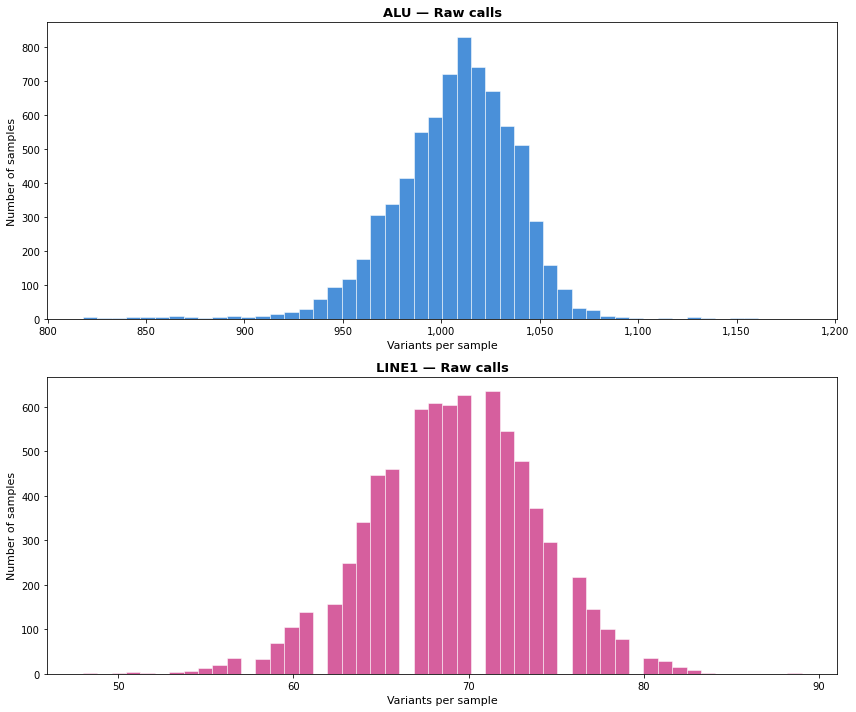

Image 1 saved.


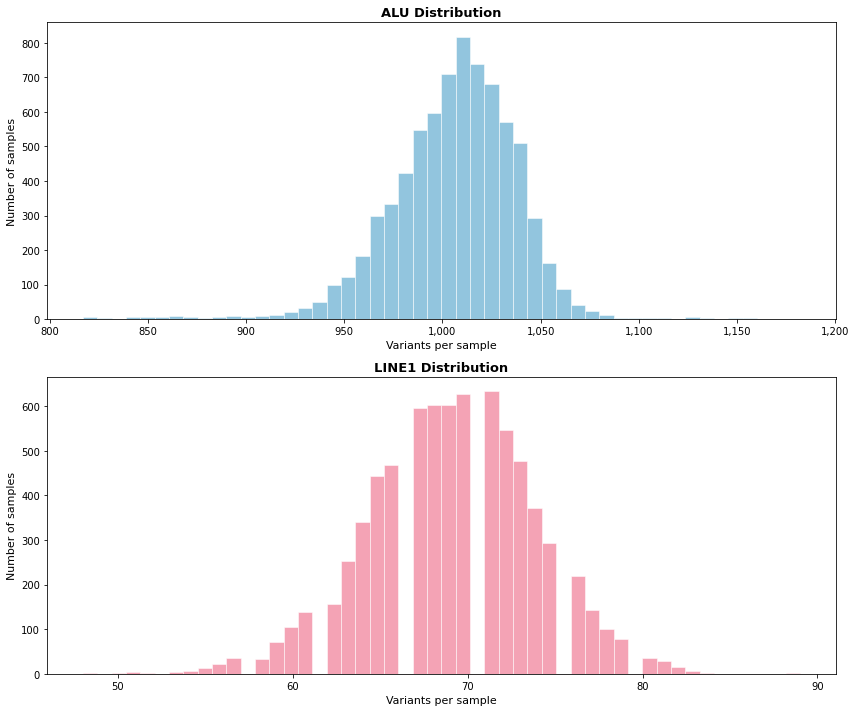

Image 2 saved.


In [5]:
def get_per_sample_counts(vcf_path):
    vcf     = pysam.VariantFile(vcf_path)
    samples = list(vcf.header.samples)
    counts  = {s: 0 for s in samples}
    for rec in vcf.fetch():
        for s in samples:
            gt = rec.samples[s]["GT"]
            if gt is not None and any(a is not None and a > 0 for a in gt):
                counts[s] += 1
    vcf.close()
    return counts

per_sample = {}
for te_type in ["ALU", "LINE1"]:
    per_sample[(te_type, "raw")]      = get_per_sample_counts(TE_CONFIG_ALL[te_type])
    per_sample[(te_type, "filtered")] = get_per_sample_counts(TE_CONFIG_25[te_type])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
fig.patch.set_facecolor("white")

for ax, te_type, color in [
    (ax1, "ALU",   "#4a90d9"),
    (ax2, "LINE1", "#D65F9E"),
]:
    ax.set_facecolor("white")
    vals = pd.Series(list(per_sample[(te_type, "raw")].values()))
    ax.hist(vals, bins=50, color=color, edgecolor="white", linewidth=0.5)
    ax.set_title(f"{te_type} — Raw calls", fontsize=13, fontweight="bold")
    ax.set_xlabel("Variants per sample", fontsize=11)
    ax.set_ylabel("Number of samples", fontsize=11)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig(f"{OUTDIR_PLOTS}/raw_calls_distribution.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()
print("Image 1 saved.")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
fig.patch.set_facecolor("white")

for ax, te_type, color in [
    (ax1, "ALU",   "#92c5de"),
    (ax2, "LINE1", "#f4a3b5"),
]:
    ax.set_facecolor("white")
    vals = pd.Series(list(per_sample[(te_type, "filtered")].values()))
    ax.hist(vals, bins=50, color=color, edgecolor="white", linewidth=0.5)
    ax.set_title(f"{te_type} Distribution", fontsize=13, fontweight="bold")
    ax.set_xlabel("Variants per sample", fontsize=11)
    ax.set_ylabel("Number of samples", fontsize=11)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig(f"{OUTDIR_PLOTS}/filtered_calls_distribution.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()
print("Image 2 saved.")

              Filter TE type  Variants  Samples  Mean/sample  Median/sample  Min/sample  Max/sample
           Raw calls     ALU      7175     7478       1006.8         1010.0         818        1183
           Raw calls   LINE1       224     7478         69.1           69.0          48          89
Missingness-filtered     ALU      6878     7478       1005.9         1009.0         817        1182
Missingness-filtered   LINE1       212     7478         69.1           69.0          48          89


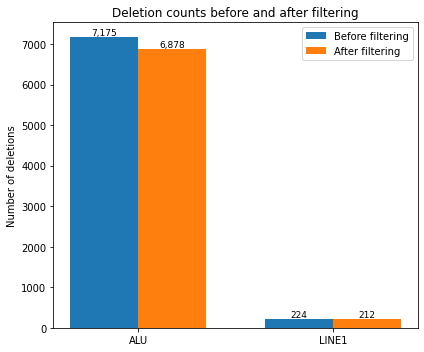

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

rows = []

for label, config, filt_key in [
    ("Raw calls", TE_CONFIG_ALL, "raw"),
    ("Missingness-filtered", TE_CONFIG_25, "filtered")
]:

    for te_type, vcf_path in config.items():

        vcf = pysam.VariantFile(vcf_path)

        n_variants = sum(
            1 for _ in vcf.fetch()
        )

        n_samples = len(
            list(vcf.header.samples)
        )

        vcf.close()

        counts = pd.Series(
            list(per_sample[(te_type, filt_key)].values())
        )

        rows.append({
            "Filter": label,
            "TE type": te_type,
            "Variants": n_variants,
            "Samples": n_samples,
            "Mean/sample": round(counts.mean(), 1),
            "Median/sample": round(counts.median(), 1),
            "Min/sample": int(counts.min()),
            "Max/sample": int(counts.max()),
        })

summary_df = pd.DataFrame(rows)

print(summary_df.to_string(index=False))

plot_df = summary_df.copy()

te_types = ["ALU", "LINE1"]

x = np.arange(len(te_types))

width = 0.35

fig, ax = plt.subplots(
    figsize=(6, 5)
)

before_counts = [
    plot_df[
        (plot_df["TE type"] == te) &
        (plot_df["Filter"] == "Raw calls")
    ]["Variants"].values[0]
    for te in te_types
]

after_counts = [
    plot_df[
        (plot_df["TE type"] == te) &
        (plot_df["Filter"] == "Missingness-filtered")
    ]["Variants"].values[0]
    for te in te_types
]

bars1 = ax.bar(
    x - width/2,
    before_counts,
    width,
    label="Before filtering"
)

bars2 = ax.bar(
    x + width/2,
    after_counts,
    width,
    label="After filtering"
)

ax.set_xticks(x)

ax.set_xticklabels(te_types)

ax.set_ylabel("Number of deletions")

ax.set_title("Deletion counts before and after filtering")

ax.legend()

for bars in [bars1, bars2]:

    for bar in bars:

        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{int(height):,}",
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()

plt.show()

In [9]:
ALU_BED   = f"{OUTDIR}/ALU.bed"
LINE1_BED = f"{OUTDIR}/LINE1.bed"
alu_rows, line1_rows = [], []

with open(MELT_BED) as f:
    for line in f:
        parts = line.strip().split("\t")
        name  = parts[3]
        if name.startswith("Alu"):
            alu_rows.append(line)
        elif name.startswith("L1"):
            line1_rows.append(line)

with open(ALU_BED,   "w") as f: f.writelines(alu_rows)
with open(LINE1_BED, "w") as f: f.writelines(line1_rows)

print(f"ALU BED:   {len(alu_rows)} entries → {ALU_BED}")
print(f"LINE1 BED: {len(line1_rows)} entries → {LINE1_BED}")

TE_BED_MAP = {"ALU": ALU_BED, "LINE1": LINE1_BED}

ALU BED:   146308 entries → /gpfs/data/user/shreyags/TE_work/analysis/deletions/benchmarking/ALU.bed
LINE1 BED: 6799 entries → /gpfs/data/user/shreyags/TE_work/analysis/deletions/benchmarking/LINE1.bed


In [11]:
from pathlib import Path

te_alu   = pd.read_csv(ALU_BED,   sep="\t", header=None,
                       names=["chr","start","end","name","score","strand"])
te_line1 = pd.read_csv(LINE1_BED, sep="\t", header=None,
                       names=["chr","start","end","name","score","strand"])

def parse_sniffles_vcf(vcf_path):
    sample  = Path(vcf_path).stem
    records = []
    with open(vcf_path) as fh:
        for line in fh:
            if line.startswith("#"):
                continue
            fields = line.strip().split("\t")
            chrom, pos, _, ref, alt, qual, filt, info = fields[:8]
            if "SVTYPE=DEL" not in info:
                continue
            start = int(pos) - 1
            end   = None
            for tag in info.split(";"):
                if tag.startswith("END="):
                    end = int(tag.split("=")[1])
            if end is None or end <= start:
                continue
            fmt_keys = fields[8].split(":") if len(fields) > 8 else []
            fmt_vals = fields[9].split(":") if len(fields) > 9 else []
            fmt = dict(zip(fmt_keys, fmt_vals))
            gt = fmt.get("GT", ".")
            records.append((chrom, start, end, sample, gt))
    return pd.DataFrame(records, columns=["chr","start","end","sample","gt"])

sniffles_vcfs_paths = [
    p for p in Path(SNIFFLES_DIR).glob("*.vcf")
    if not p.stem.endswith("_ins")
    and p.stem in overlap
]
print(f"Found {len(sniffles_vcfs_paths)} Sniffles VCFs for overlap samples")

all_dels = pd.concat([parse_sniffles_vcf(v) for v in sniffles_vcfs_paths], ignore_index=True)
print(f"Total Sniffles DELs across 16 samples: {len(all_dels)}")

for te_type, te_df in [("ALU", te_alu), ("LINE1", te_line1)]:
    print(f"\n=== {te_type} ===")
    for sample in sorted(overlap):
        sniffles_bed = f"{OUTDIR}/{sample}.{te_type}.TE.del.bed"
        
        samp_dels = all_dels[all_dels["sample"] == sample].copy()
        if len(samp_dels) == 0:
            print(f"  {sample}: no Sniffles DELs, skipping")
            open(sniffles_bed, "w").close()
            continue

        # merge on chromosome then compute offsets
        hits = samp_dels.merge(te_df, on="chr", suffixes=("_del", "_te"))
        hits["left_offset"]  = hits["start_te"] - hits["start_del"]
        hits["right_offset"] = hits["end_del"]   - hits["end_te"]

        # keep only where BOTH boundaries within 50 bp
        hits_50 = hits[
            (hits["left_offset"].abs()  <= 50) &
            (hits["right_offset"].abs() <= 50)
        ].copy()

        # write to BED — just chr, start, end to match what cells 7/8 expect
        hits_50[["chr","start_del","end_del"]].rename(
            columns={"start_del":"start","end_del":"end"}
        ).to_csv(sniffles_bed, sep="\t", header=False, index=False)

        n = len(hits_50)
        print(f"  {sample} {te_type}: {n} Sniffles DELs with both breakpoints within 50 bp of TE boundary")

print("\nSniffles TE-boundary filtering done.")

Found 16 Sniffles VCFs for overlap samples
Total Sniffles DELs across 16 samples: 192108

=== ALU ===
  AP97317807JI ALU: 1167 Sniffles DELs with both breakpoints within 50 bp of TE boundary
  AR21470926BU ALU: 1155 Sniffles DELs with both breakpoints within 50 bp of TE boundary
  BV84758993ZD ALU: 1117 Sniffles DELs with both breakpoints within 50 bp of TE boundary
  CS37349708SW ALU: 1147 Sniffles DELs with both breakpoints within 50 bp of TE boundary
  EE01709405UW ALU: 1171 Sniffles DELs with both breakpoints within 50 bp of TE boundary
  FU52780557SM ALU: 1120 Sniffles DELs with both breakpoints within 50 bp of TE boundary
  GY49105560UL ALU: 1156 Sniffles DELs with both breakpoints within 50 bp of TE boundary
  HO76179874OQ ALU: 1138 Sniffles DELs with both breakpoints within 50 bp of TE boundary
  KN45604014OF ALU: 1159 Sniffles DELs with both breakpoints within 50 bp of TE boundary
  OB84743249OV ALU: 1170 Sniffles DELs with both breakpoints within 50 bp of TE boundary
  PH3322

In [12]:
def build_truth_df(te_config, overlap):
    truth_records = []
    for te_type, vcf_path in te_config.items():
        vcf     = pysam.VariantFile(vcf_path)
        samples = list(vcf.header.samples)
        print(f"{te_type}: {len(samples)} samples in VCF")
        print(f"First 5 raw sample names: {samples[:5]}")
        stripped = [s.split("_")[0] for s in samples]
        print(f"First 5 stripped:         {stripped[:5]}")
        matched = [s for s in stripped if s in overlap]
        print(f"Matched to overlap:       {len(matched)} — {sorted(matched)}")
        for rec in vcf.fetch():
            for s in samples:
                gt = rec.samples[s]["GT"]
                if gt is None or all(a is None for a in gt):
                    continue
                if not any(a is not None and a > 0 for a in gt):
                    continue
                sample_stripped = s.split("_")[0]
                if sample_stripped not in overlap:
                    continue
                genotype = "hom" if all(a == 1 for a in gt if a is not None) else "het"
                truth_records.append({
                    "te_type":  te_type,
                    "sample":   sample_stripped,
                    "chrom":    rec.chrom,
                    "start":    rec.pos - 1,
                    "end":      rec.stop,
                    "genotype": genotype,
                    "category": rec.id if rec.id else f"{rec.chrom}:{rec.pos}",
                })
        vcf.close()
    df = pd.DataFrame(truth_records)
    df["validated"] = False
    return df

truth_df_raw  = build_truth_df(TE_CONFIG_ALL, overlap)
truth_df_filt = build_truth_df(TE_CONFIG_25,  overlap)

print(f"truth_df_raw shape:  {truth_df_raw.shape}")
print(f"truth_df_filt shape: {truth_df_filt.shape}")
print(truth_df_raw.groupby(["te_type", "sample"]).size().reset_index(name="n_loci").to_string(index=False))

ALU: 7478 samples in VCF
First 5 raw sample names: ['AA05259566XS_md', 'AA11843508AL_md', 'AA13901862BS_md', 'AA52095125YZ_md', 'AA66719668QC_md']
First 5 stripped:         ['AA05259566XS', 'AA11843508AL', 'AA13901862BS', 'AA52095125YZ', 'AA66719668QC']
Matched to overlap:       16 — ['AP97317807JI', 'AR21470926BU', 'BV84758993ZD', 'CS37349708SW', 'EE01709405UW', 'FU52780557SM', 'GY49105560UL', 'HO76179874OQ', 'KN45604014OF', 'OB84743249OV', 'PH33227146TP', 'SF20790699II', 'UT72239905LP', 'WA39086099MA', 'YQ42560871PO', 'ZR29322449IE']
LINE1: 7478 samples in VCF
First 5 raw sample names: ['AA05259566XS_md', 'AA11843508AL_md', 'AA13901862BS_md', 'AA52095125YZ_md', 'AA66719668QC_md']
First 5 stripped:         ['AA05259566XS', 'AA11843508AL', 'AA13901862BS', 'AA52095125YZ', 'AA66719668QC']
Matched to overlap:       16 — ['AP97317807JI', 'AR21470926BU', 'BV84758993ZD', 'CS37349708SW', 'EE01709405UW', 'FU52780557SM', 'GY49105560UL', 'HO76179874OQ', 'KN45604014OF', 'OB84743249OV', 'PH3322714

In [13]:
for label, truth_df in [("raw", truth_df_raw), ("filt", truth_df_filt)]:
    for (te_type, sample), subdf in truth_df.groupby(["te_type", "sample"]):
        outbed = f"{OUTDIR}/{sample}.{te_type}.{label}.melt.truth.bed"
        subdf  = subdf.sort_values(["chrom", "start", "end"])
        subdf[["chrom", "start", "end", "category", "genotype"]].to_csv(
            outbed, sep="\t", header=False, index=False
        )
        print(f"  {sample} {te_type} {label}: {len(subdf)} loci")
print("\nMELT truth BEDs written.")

  AP97317807JI ALU raw: 1029 loci
  AR21470926BU ALU raw: 1025 loci
  BV84758993ZD ALU raw: 982 loci
  CS37349708SW ALU raw: 1041 loci
  EE01709405UW ALU raw: 1041 loci
  FU52780557SM ALU raw: 960 loci
  GY49105560UL ALU raw: 1002 loci
  HO76179874OQ ALU raw: 959 loci
  KN45604014OF ALU raw: 1006 loci
  OB84743249OV ALU raw: 1014 loci
  PH33227146TP ALU raw: 1017 loci
  SF20790699II ALU raw: 964 loci
  UT72239905LP ALU raw: 1015 loci
  WA39086099MA ALU raw: 1002 loci
  YQ42560871PO ALU raw: 1013 loci
  ZR29322449IE ALU raw: 1014 loci
  AP97317807JI LINE1 raw: 71 loci
  AR21470926BU LINE1 raw: 66 loci
  BV84758993ZD LINE1 raw: 70 loci
  CS37349708SW LINE1 raw: 70 loci
  EE01709405UW LINE1 raw: 72 loci
  FU52780557SM LINE1 raw: 70 loci
  GY49105560UL LINE1 raw: 63 loci
  HO76179874OQ LINE1 raw: 61 loci
  KN45604014OF LINE1 raw: 64 loci
  OB84743249OV LINE1 raw: 72 loci
  PH33227146TP LINE1 raw: 75 loci
  SF20790699II LINE1 raw: 62 loci
  UT72239905LP LINE1 raw: 72 loci
  WA39086099MA LIN

In [14]:
for label, truth_df in [("raw", truth_df_raw), ("filt", truth_df_filt)]:
    for te_type in TE_CONFIG_ALL.keys():
        print(f"\n=== {te_type} {label} ===")
        for sample in sorted(overlap):
            truth_bed     = f"{OUTDIR}/{sample}.{te_type}.{label}.melt.truth.bed"
            sniffles_bed  = f"{OUTDIR}/{sample}.{te_type}.TE.del.bed"
            validated_out = f"{OUTDIR}/{sample}.{te_type}.{label}.validated.tsv"

            if not os.path.exists(truth_bed):
                print(f"  {sample}: no truth BED, skipping")
                continue
            if not os.path.exists(sniffles_bed) or os.path.getsize(sniffles_bed) == 0:
                print(f"  {sample}: no Sniffles DELs, skipping")
                open(validated_out, "w").close()
                continue

            cmd = (
                f"module load bedtools-2.30 && "
                f"bedtools intersect -wa -u -f 0.8 -r "
                f"-a {truth_bed} -b {sniffles_bed} > {validated_out}"
            )
            result = subprocess.run(cmd, shell=True, executable="/bin/bash",
                                    capture_output=True, text=True)
            if result.returncode != 0:
                print(f"  {sample}: bedtools error — {result.stderr.strip()}")
            else:
                n = sum(1 for _ in open(validated_out)) if os.path.getsize(validated_out) > 0 else 0
                print(f"  {sample} {te_type} {label}: {n} MELT loci validated by Sniffles")

print("\nValidation intersections done.")


=== ALU raw ===
  AP97317807JI ALU raw: 1009 MELT loci validated by Sniffles
  AR21470926BU ALU raw: 1004 MELT loci validated by Sniffles
  BV84758993ZD ALU raw: 959 MELT loci validated by Sniffles
  CS37349708SW ALU raw: 1006 MELT loci validated by Sniffles
  EE01709405UW ALU raw: 1022 MELT loci validated by Sniffles
  FU52780557SM ALU raw: 944 MELT loci validated by Sniffles
  GY49105560UL ALU raw: 986 MELT loci validated by Sniffles
  HO76179874OQ ALU raw: 841 MELT loci validated by Sniffles
  KN45604014OF ALU raw: 988 MELT loci validated by Sniffles
  OB84743249OV ALU raw: 998 MELT loci validated by Sniffles
  PH33227146TP ALU raw: 1002 MELT loci validated by Sniffles
  SF20790699II ALU raw: 858 MELT loci validated by Sniffles
  UT72239905LP ALU raw: 1000 MELT loci validated by Sniffles
  WA39086099MA ALU raw: 814 MELT loci validated by Sniffles
  YQ42560871PO ALU raw: 1000 MELT loci validated by Sniffles
  ZR29322449IE ALU raw: 994 MELT loci validated by Sniffles

=== LINE1 raw =

In [ ]:
import os

save_dir = os.path.expanduser("~/TE_work/data/deltruth")
os.makedirs(save_dir, exist_ok=True)

for label, truth_df in [("raw", truth_df_raw), ("filt", truth_df_filt)]:

    for te_type in TE_CONFIG_ALL.keys():

        for sample in sorted(overlap):

            validated_out = f"{OUTDIR}/{sample}.{te_type}.{label}.validated.tsv"

            if not os.path.exists(validated_out) or os.path.getsize(validated_out) == 0:
                continue

            val_df = pd.read_csv(
                validated_out,
                sep="\t",
                header=None,
                names=["chrom", "start", "end", "category", "genotype"]
            )

            val_keys = set(
                val_df["chrom"] + "_" +
                val_df["start"].astype(str) + "_" +
                val_df["end"].astype(str)
            )

            mask = (
                (truth_df["te_type"] == te_type) &
                (truth_df["sample"]  == sample)
            )

            truth_df.loc[mask, "validated"] = (
                truth_df.loc[mask, "chrom"] + "_" +
                truth_df.loc[mask, "start"].astype(str) + "_" +
                truth_df.loc[mask, "end"].astype(str)
            ).isin(val_keys)


    out_csv = f"{save_dir}/truth_df_{label}.csv"

    truth_df.to_csv(out_csv, index=False)

    print(f"Saved: {out_csv}")


print(
    f"\nRaw validated: "
    f"{truth_df_raw['validated'].sum()} / {len(truth_df_raw)}"
)

print(
    f"Filtered validated: "
    f"{truth_df_filt['validated'].sum()} / {len(truth_df_filt)}"
)

Saved: /gpfs/data/user/shreyags/TE_work/data/deltruth/truth_df_raw.csv
Saved: /gpfs/data/user/shreyags/TE_work/data/deltruth/truth_df_filt.csv

Raw validated: 16416 / 17180
Filtered validated: 16416 / 17172


In [16]:
def run_benchmarking(truth_df_input):
    rows = []
    for te_type in ["ALU", "LINE1"]:
        grp = truth_df_input[truth_df_input["te_type"] == te_type]
        for sample in sorted(grp["sample"].unique()):
            sgrp         = grp[grp["sample"] == sample]
            sniffles_bed = f"{OUTDIR}/{sample}.{te_type}.TE.del.bed"
            n_sniffles   = 0
            if os.path.exists(sniffles_bed) and os.path.getsize(sniffles_bed) > 0:
                n_sniffles = sum(1 for _ in open(sniffles_bed))
            tp        = sgrp["validated"].sum()
            fp        = (~sgrp["validated"]).sum()
            fn        = max(0, n_sniffles - tp)
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1        = (2 * precision * recall / (precision + recall)
                         if (precision + recall) > 0 else 0)
            rows.append({
                "te_type":    te_type, "sample": sample,
                "TP":         tp,  "FP": fp, "FN": fn,
                "precision":  round(precision, 3),
                "recall":     round(recall, 3),
                "f1":         round(f1, 3),
                "n_melt":     len(sgrp),
                "n_sniffles": n_sniffles,
            })
    return pd.DataFrame(rows)

bench_raw  = run_benchmarking(truth_df_raw)
bench_filt = run_benchmarking(truth_df_filt)

metrics = ["TP", "FP", "FN", "precision", "recall", "f1", "n_melt", "n_sniffles"]

for te_type in ["ALU", "LINE1"]:
    raw_grp  = bench_raw[bench_raw["te_type"]   == te_type][["sample"] + metrics].reset_index(drop=True)
    filt_grp = bench_filt[bench_filt["te_type"] == te_type][["sample"] + metrics].reset_index(drop=True)

    for df in [raw_grp, filt_grp]:
        mean_row           = df[metrics].mean().round(3).to_dict()
        mean_row["sample"] = "MEAN"
        median_row           = df[metrics].median().round(3).to_dict()
        median_row["sample"] = "MEDIAN"
        df.loc[len(df)] = mean_row
        df.loc[len(df)] = median_row

    raw_grp  = raw_grp.rename(columns={m: f"{m}_raw"  for m in metrics})
    filt_grp = filt_grp.rename(columns={m: f"{m}_filt" for m in metrics})

    combined = raw_grp.merge(filt_grp, on="sample")

    interleaved = ["sample"] + [f"{m}_{s}" for m in metrics for s in ("raw", "filt")]
    combined = combined[interleaved]

    combined.columns = pd.MultiIndex.from_arrays([
        ["sample"] + [m   for m in metrics for _ in ("raw", "filtered")],
        [""]       + [sub for _ in metrics for sub in ("raw", "filtered")],
    ])

    def highlight_summary(row):
        if row[("sample", "")] in ["MEAN", "MEDIAN"]:
            return ["background-color: #d0e8ff; font-weight: bold"] * len(row)
        return [""] * len(row)

    styled = (
        combined.style
        .apply(highlight_summary, axis=1)
        .set_table_styles([
            {"selector": "th", "props": [
                ("border", "1px solid black"),
                ("background-color", "#404040"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("padding", "6px"),
                ("text-align", "center"),
            ]},
            {"selector": "td", "props": [
                ("border", "1px solid #aaa"),
                ("padding", "5px"),
            ]},
            {"selector": "table", "props": [
                ("border-collapse", "collapse"),
                ("width", "100%"),
            ]},
        ])
        .hide_index()
    )

    print(f"\n{'='*60}")
    print(f"{te_type} — Benchmarking: Raw vs Missingness-filtered")
    print(f"{'='*60}")
    display(styled)

    combined.to_csv(f"{OUTDIR}/benchmark_combined_{te_type}.tsv", sep="\t", index=False)

print("\nDone.")


ALU — Benchmarking: Raw vs Missingness-filtered



LINE1 — Benchmarking: Raw vs Missingness-filtered



Done.


In [34]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

loci = [
    ("chr1", 9063688, 9063995), ("chr1", 54316347, 54316698), ("chr1", 56776952, 56777274), ("chr1", 100923007, 100923316), ("chr1", 155027387, 155027388), ("chr1", 184967920, 184968228), ("chr1", 210121975, 210122278), ("chr1", 216011974, 216012135), ("chr1", 222887491, 222887798), ("chr1", 225574612, 225574924), ("chr1", 235400418, 235400738), ("chr10", 68874578, 68874681), ("chr10", 73038627, 73038926), ("chr10", 102768380, 102768691), ("chr10", 116963041, 116963372), ("chr11", 33516141, 33516452), ("chr11", 74821378, 74821679), ("chr11", 92512835, 92513136), ("chr11", 128571472, 128571520), ("chr11", 132213732, 132214033), ("chr12", 64741064, 64741224), ("chr13", 79507272, 79507574), ("chr13", 99026026, 99026098), ("chr14", 34836097, 34836416), ("chr14", 70971119, 70971444), ("chr14", 88423674, 88423833), ("chr15", 26776349, 26776650), ("chr15", 43368240, 43368556), ("chr15", 58620666, 58620968), ("chr15", 67242138, 67242462), ("chr15", 68691337, 68691612), ("chr15", 71593142, 71593475), ("chr15", 94267883, 94268185), ("chr16", 20767231, 20767540), ("chr16", 67479917, 67480221), ("chr17", 75044204, 75044505), ("chr17", 81643286, 81643629), ("chr18", 12851197, 12851513), ("chr18", 25312526, 25312841), ("chr18", 58134360, 58134672), ("chr18", 62061435, 62061529), ("chr19", 910885, 911172), ("chr19", 4843199, 4843511), ("chr19", 8449541, 8449834), ("chr19", 23803609, 23803915), ("chr19", 45400766, 45401077), ("chr2", 73203817, 73204116), ("chr2", 85291998, 85292320), ("chr2", 101740153, 101740454), ("chr2", 121495008, 121495329), ("chr2", 230460594, 230460923), ("chr2", 237681680, 237681941), ("chr20", 35033858, 35034168), ("chr22", 32899782, 32900091), ("chr22", 43153339, 43153604), ("chr3", 12310463, 12310763), ("chr3", 17690208, 17690516), ("chr3", 42989614, 42989929), ("chr3", 52499617, 52499921), ("chr3", 131958971, 131959300), ("chr3", 185587584, 185587733), ("chr4", 85643235, 85643558), ("chr4", 85739616, 85739929), ("chr4", 109577601, 109577910), ("chr4", 139026873, 139027180), ("chr4", 141005783, 141006088), ("chr5", 11338930, 11339238), ("chr5", 84319185, 84319522), ("chr5", 154744630, 154744939), ("chr6", 159231085, 159231391), ("chr7", 27743796, 27744105), ("chr7", 87207308, 87207608), ("chr7", 99462214, 99462499), ("chr7", 105667416, 105667719), ("chr7", 117201963, 117202264), ("chr7", 135504467, 135504786), ("chr7", 152385331, 152385645), ("chr8", 51454957, 51455132), ("chr8", 54140591, 54140875), ("chr9", 33050836, 33051137), ("chr9", 34181133, 34181378), ("chr9", 95503733, 95504051), ("chr9", 131294992, 131295105), ("chrX", 33190476, 33190787), ("chrX", 123864661, 123864792)
]

summary_rows = []

for chrom, start, end in loci:

    sub = truth_df[
        (truth_df["chrom"] == chrom) &
        (truth_df["start"] <= end) &
        (truth_df["end"] >= start)
    ].copy()

    n_true = sub["validated"].sum()
    n_false = (~sub["validated"]).sum()
    total = len(sub)

    false_fraction = (
        n_false / total
        if total > 0 else 0
    )

    summary_rows.append({
        "query_locus": f"{chrom}:{start}-{end}",
        "validated_TRUE_samples": int(n_true),
        "validated_FALSE_samples": int(n_false),
        "total_matching_samples": int(total),
        "false_fraction": round(false_fraction, 3),
        "false_gt_50pct": false_fraction > 0.5,
    })

print("INTRONIC ALU")

summary_df = pd.DataFrame(summary_rows)

display(
    summary_df
    .sort_values("query_locus")
    .style
    .set_properties(**{
        "white-space": "nowrap"
    })
)

n_total_loci = len(summary_df)

n_false_gt_50 = (
    summary_df["false_gt_50pct"]
    .sum()
)

print(
    f"\nLoci with >50% FALSE samples: "
    f"{n_false_gt_50} / {n_total_loci}"
)

INTRONIC ALU


,query_locus,validated_TRUE_samples,validated_FALSE_samples,total_matching_samples,false_fraction,false_gt_50pct
13,chr10:102768380-102768691,11,0,11,0.000000,False
14,chr10:116963041-116963372,3,0,3,0.000000,False
11,chr10:68874578-68874681,11,1,12,0.083000,False
12,chr10:73038627-73038926,5,0,5,0.000000,False
18,chr11:128571472-128571520,0,1,1,1.000000,True
19,chr11:132213732-132214033,4,0,4,0.000000,False
15,chr11:33516141-33516452,12,1,13,0.077000,False
16,chr11:74821378-74821679,11,0,11,0.000000,False
17,chr11:92512835-92513136,12,1,13,0.077000,False
20,chr12:64741064-64741224,11,1,12,0.083000,False



Loci with >50% FALSE samples: 8 / 85


In [33]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

loci_1 = [
    ("chr1", 31401194, 31401199), ("chr1", 46337013, 46337332), ("chr1", 46337675, 46337953), ("chr1", 156758303, 156758605), ("chr1", 218612588, 218612897), ("chr1", 224205132, 224205433), ("chr1", 232287387, 232287701), ("chr1", 235891291, 235891614), ("chr10", 10666576, 10666890), ("chr10", 24809160, 24809491), ("chr10", 26686933, 26686947), ("chr10", 42778763, 42779085), ("chr10", 73417850, 73418165), ("chr10", 109276634, 109276940), ("chr10", 114101968, 114102272), ("chr10", 128137314, 128137569), ("chr10", 128148309, 128148621), ("chr13", 47115354, 47115656), ("chr13", 69462272, 69462586), ("chr13", 72382568, 72382881), ("chr16", 25612248, 25612541), ("chr16", 30679437, 30679761), ("chr18", 46170726, 46171043), ("chr18", 49493495, 49493804), ("chr18", 78237296, 78237616), ("chr19", 3994562, 3994874), ("chr19", 18550489, 18550793), ("chr19", 29895626, 29895835), ("chr19", 46452848, 46453172), ("chr2", 42902140, 42902414), ("chr2", 106322018, 106322332), ("chr2", 133786715, 133787036), ("chr2", 151760787, 151761090), ("chr2", 156415874, 156416044), ("chr2", 207702499, 207702806), ("chr2", 238500741, 238501057), ("chr20", 50156254, 50156555), ("chr21", 37589413, 37589681), ("chr21", 38218620, 38218951), ("chr22", 36401991, 36402296), ("chr3", 31502152, 31502476), ("chr3", 45568430, 45568728), ("chr3", 102564943, 102565269), ("chr4", 82258638, 82258938), ("chr4", 119092661, 119092968), ("chr4", 119323418, 119323749), ("chr4", 146663610, 146663923), ("chr5", 166723758, 166724064), ("chr6", 106676654, 106676953), ("chr7", 150765978, 150766303), ("chr8", 130676472, 130676802), ("chr9", 2000984, 2001295), ("chr9", 36423663, 36423974), ("chr9", 71654480, 71654751), ("chr9", 81821882, 81822209), ("chr9", 81862171, 81862490), ("chr9", 133185341, 133185646)
]

summary_rows = []

for chrom, start, end in loci_1:

    sub = truth_df[
        (truth_df["chrom"] == chrom) &
        (truth_df["start"] <= end) &
        (truth_df["end"] >= start)
    ].copy()

    n_true = sub["validated"].sum()
    n_false = (~sub["validated"]).sum()
    total = len(sub)

    false_fraction = (
        n_false / total
        if total > 0 else 0
    )

    summary_rows.append({
        "query_locus": f"{chrom}:{start}-{end}",
        "validated_TRUE_samples": int(n_true),
        "validated_FALSE_samples": int(n_false),
        "total_matching_samples": int(total),
        "false_fraction": round(false_fraction, 3),
        "false_gt_50pct": false_fraction > 0.5,
    })
    
print("INTERGENIC ALU")

summary_df = pd.DataFrame(summary_rows)

display(
    summary_df
    .sort_values("query_locus")
    .style
    .set_properties(**{
        "white-space": "nowrap"
    })
)

n_total_loci = len(summary_df)

n_false_gt_50 = (
    summary_df["false_gt_50pct"]
    .sum()
)

print(
    f"\nLoci with >50% FALSE samples: "
    f"{n_false_gt_50} / {n_total_loci}"
)

INTERGENIC ALU


,query_locus,validated_TRUE_samples,validated_FALSE_samples,total_matching_samples,false_fraction,false_gt_50pct
8,chr10:10666576-10666890,10,0,10,0.000000,False
13,chr10:109276634-109276940,2,0,2,0.000000,False
14,chr10:114101968-114102272,2,0,2,0.000000,False
15,chr10:128137314-128137569,5,1,6,0.167000,False
16,chr10:128148309-128148621,3,1,4,0.250000,False
9,chr10:24809160-24809491,16,0,16,0.000000,False
10,chr10:26686933-26686947,0,5,5,1.000000,True
11,chr10:42778763-42779085,12,0,12,0.000000,False
12,chr10:73417850-73418165,0,0,0,0.000000,False
17,chr13:47115354-47115656,16,0,16,0.000000,False



Loci with >50% FALSE samples: 6 / 57


In [20]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

loci_4 = [
("chr1", 12816082, 12816357), ("chr1", 56365451, 56369290), ("chr1", 65443955, 65444210), ("chr1", 86275303, 86276015), ("chr1", 91448554, 91448994), ("chr1", 184845609, 184851651), ("chr1", 218072296, 218073148), ("chr1", 247687171, 247693207), ("chr2", 4733720, 4739767), ("chr2", 88729728, 88732766), ("chr2", 175481954, 175487994), ("chr2", 195187096, 195187361), ("chr2", 238980701, 238980866), ("chr3", 33511715, 33512584), ("chr3", 80876163, 80877454), ("chr3", 83803977, 83806199), ("chr4", 44505262, 44505717), ("chr4", 57221179, 57221569), ("chr4", 59078847, 59084884), ("chr4", 70242276, 70242479), ("chr4", 74717544, 74723590), ("chr4", 78347977, 78354042), ("chr4", 79966908, 79972938), ("chr4", 93638303, 93644340), ("chr4", 102951962, 102954451), ("chr4", 138547724, 138552086), ("chr4", 151419570, 151420401), ("chr5", 104518587, 104524626), ("chr5", 109259388, 109265421), ("chr5", 133583289, 133589300), ("chr5", 152076869, 152082887), ("chr6", 24811659, 24817723), ("chr6", 51874779, 51880803), ("chr6", 68432288, 68433216), ("chr6", 74155732, 74156869), ("chr6", 84608440, 84614503), ("chr6", 110155538, 110158565), ("chr6", 133020695, 133026747), ("chr6", 159547185, 159549806), ("chr7", 56584797, 56590823), ("chr7", 93787629, 93793680), ("chr7", 113776121, 113782153), ("chr7", 144685667, 144685810), ("chr8", 16689254, 16689340), ("chr8", 18597110, 18598435), ("chr8", 47331986, 47331989), ("chr8", 72875540, 72881589), ("chr8", 76425150, 76426192), ("chr8", 125582885, 125588891), ("chr9", 10136559, 10137715), ("chr9", 101681697, 101682446), ("chr9", 132526549, 132529524), ("chr10", 15915724, 15921764), ("chr10", 19088572, 19088594), ("chr10", 29423225, 29423792), ("chr11", 24327949, 24334003), ("chr11", 41075014, 41075137), ("chr11", 93136637, 93142685), ("chr11", 95436213, 95442257), ("chr11", 122476876, 122478573), ("chr12", 61901264, 61901442), ("chr12", 97717929, 97718980), ("chr14", 24001959, 24003964), ("chr14", 51937627, 51937740), ("chr15", 82882879, 82888924), ("chr16", 18821222, 18827055), ("chr16", 83637247, 83643308), ("chr17", 31332573, 31332924), ("chr18", 43451587, 43452564), ("chr20", 43395972, 43397153), ("chr20", 55859567, 55865561), ("chr21", 25452833, 25453087), ("chrX", 11707246, 11713280), ("chrX", 16409568, 16410090), ("chrX", 78441360, 78441954), ("chrX", 81841154, 81847194), ("chrX", 96057780, 96063846), ("chrX", 141421207, 141427248), ("chrX", 146861645, 146862432), ("chrX", 147477731, 147477828)
]

summary_rows = []

for chrom, start, end in loci_4:
    sub = truth_df_filt[
        (truth_df_filt["chrom"] == chrom) &
        (truth_df_filt["start"] <= end) &
        (truth_df_filt["end"] >= start)
    ].copy()

    n_true         = sub["validated"].sum()
    n_false        = (~sub["validated"]).sum()
    total          = len(sub)
    present        = total > 0
    false_fraction = n_false / total if total > 0 else 0

    summary_rows.append({
        "query_locus":             f"{chrom}:{start}-{end}",
        "present_in_lr_samples":   present,
        "validated_TRUE_samples":  int(n_true),
        "validated_FALSE_samples": int(n_false),
        "total_matching_samples":  int(total),
        "false_fraction":          round(false_fraction, 3),
        "false_gt_50pct":          false_fraction > 0.5,
    })

print("Common LINE1s not present in 1KGP longreads")

summary_df = pd.DataFrame(summary_rows)

display(
    summary_df
    .sort_values("query_locus")
    .style
    .set_properties(**{"white-space": "nowrap"})
)

n_total_loci   = len(summary_df)
n_present      = summary_df["present_in_lr_samples"].sum()
n_false_gt_50  = summary_df[summary_df["present_in_lr_samples"]]["false_gt_50pct"].sum()

print(f"\n{n_present} / {n_total_loci} loci present/genotyped in the LR samples")
print(f"{n_false_gt_50} / {n_present} loci with >50% FALSE validation rate (of those present)")

Common LINE1s not present in 1KGP longreads


,query_locus,present_in_lr_samples,validated_TRUE_samples,validated_FALSE_samples,total_matching_samples,false_fraction,false_gt_50pct
52,chr10:15915724-15921764,False,0,0,0,0.000000,False
53,chr10:19088572-19088594,True,0,1,1,1.000000,True
54,chr10:29423225-29423792,True,0,10,10,1.000000,True
59,chr11:122476876-122478573,True,16,0,16,0.000000,False
55,chr11:24327949-24334003,True,6,0,6,0.000000,False
56,chr11:41075014-41075137,True,9,1,10,0.100000,False
57,chr11:93136637-93142685,True,12,1,13,0.077000,False
58,chr11:95436213-95442257,True,5,1,6,0.167000,False
60,chr12:61901264-61901442,True,14,0,14,0.000000,False
61,chr12:97717929-97718980,True,2,0,2,0.000000,False



76 / 80 loci present/genotyped in the LR samples
7 / 76 loci with >50% FALSE validation rate (of those present)


In [22]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

loci_4 = [
("chr1", 12816082, 12816357), ("chr1", 56365451, 56369290), ("chr1", 74518845, 74519570), ("chr1", 91448554, 91448994), ("chr1", 184845609, 184851651), ("chr1", 247687171, 247693207), ("chr2", 4733720, 4739767), ("chr2", 88729728, 88732766), ("chr2", 134209146, 134212560), ("chr2", 142031333, 142031544), ("chr2", 169248624, 169254653), ("chr2", 175481954, 175487994), ("chr2", 238980701, 238980866), ("chr3", 7305342, 7305641), ("chr3", 60699597, 60699707), ("chr3", 80876163, 80877454), ("chr3", 83803977, 83806199), ("chr3", 121036778, 121036850), ("chr3", 137353524, 137354605), ("chr4", 59078847, 59084884), ("chr4", 70242276, 70242479), ("chr4", 74717544, 74723590), ("chr4", 78347977, 78354042), ("chr4", 79966908, 79972938), ("chr4", 82008157, 82010239), ("chr4", 87347108, 87353147), ("chr4", 93638303, 93644340), ("chr4", 102951962, 102954451), ("chr4", 129295361, 129298328), ("chr4", 138547724, 138552086), ("chr4", 166755897, 166761921), ("chr4", 181774006, 181775007), ("chr5", 41599348, 41600022), ("chr5", 104518587, 104524626), ("chr5", 109259388, 109265421), ("chr5", 133583289, 133589300), ("chr5", 145093711, 145094078), ("chr5", 152076869, 152082887), ("chr6", 19764894, 19770954), ("chr6", 51874779, 51880803), ("chr6", 68432288, 68433216), ("chr6", 74155732, 74156869), ("chr6", 84608440, 84614503), ("chr6", 110155538, 110158565), ("chr6", 133020695, 133026747), ("chr6", 159547185, 159549806), ("chr7", 32350553, 32353501), ("chr7", 49680252, 49686302), ("chr7", 113776121, 113782153), ("chr7", 141920675, 141926713), ("chr7", 144685667, 144685810), ("chr8", 16689254, 16689340), ("chr8", 18597110, 18598435), ("chr8", 47331986, 47331989), ("chr8", 72875540, 72881589), ("chr8", 76425150, 76426192), ("chr8", 125582885, 125588891), ("chr9", 10136559, 10137715), ("chr9", 132526549, 132529524), ("chr10", 5245352, 5251383), ("chr10", 6369618, 6375668), ("chr10", 19088572, 19088594), ("chr11", 24327949, 24334003), ("chr11", 49104081, 49106082), ("chr11", 85500265, 85500577), ("chr11", 93136637, 93142685), ("chr11", 95436213, 95442257), ("chr11", 122476876, 122478573), ("chr12", 17741236, 17741455), ("chr12", 61901264, 61901442), ("chr12", 97717929, 97718980), ("chr13", 29641700, 29647708), ("chr14", 24001959, 24003964), ("chr14", 83169509, 83170140), ("chr16", 18821222, 18827055), ("chr16", 83637247, 83643308), ("chr17", 31332573, 31332924), ("chr18", 43451587, 43452564), ("chr20", 7116146, 7122200), ("chr20", 43395972, 43397153), ("chrX", 11707246, 11713280), ("chrX", 81841154, 81847194), ("chrX", 96057780, 96063846), ("chrX", 141421207, 141427248), ("chrX", 146861645, 146862432)
]

summary_rows = []

for chrom, start, end in loci_4:
    sub = truth_df_filt[
        (truth_df_filt["chrom"] == chrom) &
        (truth_df_filt["start"] <= end) &
        (truth_df_filt["end"] >= start)
    ].copy()

    n_true         = sub["validated"].sum()
    n_false        = (~sub["validated"]).sum()
    total          = len(sub)
    present        = total > 0
    false_fraction = n_false / total if total > 0 else 0

    summary_rows.append({
        "query_locus":             f"{chrom}:{start}-{end}",
        "present_in_lr_samples":   present,
        "validated_TRUE_samples":  int(n_true),
        "validated_FALSE_samples": int(n_false),
        "total_matching_samples":  int(total),
        "false_fraction":          round(false_fraction, 3),
        "false_gt_50pct":          false_fraction > 0.5,
    })

print("Common LINE1s not present in 1KGP shortreads")

summary_df = pd.DataFrame(summary_rows)

display(
    summary_df
    .sort_values("query_locus")
    .style
    .set_properties(**{"white-space": "nowrap"})
)

n_total_loci   = len(summary_df)
n_present      = summary_df["present_in_lr_samples"].sum()
n_false_gt_50  = summary_df[summary_df["present_in_lr_samples"]]["false_gt_50pct"].sum()

print(f"\n{n_present} / {n_total_loci} loci present/genotyped in the LR samples")
print(f"{n_false_gt_50} / {n_present} loci with >50% FALSE validation rate (of those present)")

Common LINE1s not present in 1KGP shortreads


,query_locus,present_in_lr_samples,validated_TRUE_samples,validated_FALSE_samples,total_matching_samples,false_fraction,false_gt_50pct
61,chr10:19088572-19088594,True,0,1,1,1.000000,True
59,chr10:5245352-5251383,True,3,1,4,0.250000,False
60,chr10:6369618-6375668,True,16,0,16,0.000000,False
67,chr11:122476876-122478573,True,16,0,16,0.000000,False
62,chr11:24327949-24334003,True,6,0,6,0.000000,False
63,chr11:49104081-49106082,False,0,0,0,0.000000,False
64,chr11:85500265-85500577,False,0,0,0,0.000000,False
65,chr11:93136637-93142685,True,12,1,13,0.077000,False
66,chr11:95436213-95442257,True,5,1,6,0.167000,False
68,chr12:17741236-17741455,True,15,0,15,0.000000,False



77 / 85 loci present/genotyped in the LR samples
9 / 77 loci with >50% FALSE validation rate (of those present)


In [21]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

loci_4 = [
("chr1", 1530594, 1530851), ("chr1", 9063688, 9063995), ("chr1", 12838207, 12838471), ("chr1", 16629197, 16629358), ("chr1", 24076521, 24076815), ("chr1", 26163327, 26163648), ("chr1", 27921296, 27921598), ("chr1", 31401194, 31401199), ("chr1", 42277516, 42277822), ("chr1", 42542542, 42542853), ("chr1", 44951959, 44952263), ("chr1", 46337013, 46337332), ("chr1", 46337675, 46337953), ("chr1", 54316347, 54316698), ("chr1", 54821889, 54822198), ("chr1", 55935616, 55935931), ("chr1", 56776952, 56777274), ("chr1", 58593962, 58594270), ("chr1", 60604045, 60604351), ("chr1", 65798240, 65798560), ("chr1", 66735539, 66735854), ("chr1", 67403928, 67403930), ("chr1", 70302439, 70302752), ("chr1", 73287924, 73288233), ("chr1", 73303109, 73303452), ("chr1", 75546196, 75546511), ("chr1", 76634690, 76634965), ("chr1", 78935840, 78936146), ("chr1", 79648500, 79648805), ("chr1", 81222111, 81222429), ("chr1", 85282951, 85283268), ("chr1", 93785911, 93786216), ("chr1", 95224966, 95225274), ("chr1", 100923007, 100923316), ("chr1", 102582134, 102582453), ("chr1", 102630524, 102630829), ("chr1", 104177237, 104177543), ("chr1", 104885698, 104886018), ("chr1", 105324161, 105324423), ("chr1", 109055105, 109055419), ("chr1", 109288251, 109288503), ("chr1", 113173023, 113173299), ("chr1", 115254281, 115254552), ("chr1", 119016159, 119016472), ("chr1", 150718970, 150719294), ("chr1", 155027387, 155027388), ("chr1", 156758303, 156758605), ("chr1", 158659597, 158659910), ("chr1", 158742257, 158742564), ("chr1", 160965241, 160965547), ("chr1", 162486968, 162487267), ("chr1", 168471643, 168471955), ("chr1", 169190799, 169191112), ("chr1", 182320199, 182320502), ("chr1", 182982888, 182983177), ("chr1", 184309605, 184309908), ("chr1", 184967920, 184968228), ("chr1", 185797684, 185798002), ("chr1", 196188929, 196189201), ("chr1", 205966754, 205967055), ("chr1", 210121975, 210122278), ("chr1", 216011974, 216012135), ("chr1", 217744179, 217744483), ("chr1", 218612588, 218612897), ("chr1", 219749981, 219750285), ("chr1", 220112129, 220112440), ("chr1", 221860812, 221861134), ("chr1", 222887491, 222887798), ("chr1", 224205132, 224205433), ("chr1", 225068843, 225069100), ("chr1", 225156711, 225157019), ("chr1", 225574612, 225574924), ("chr1", 227294575, 227294882), ("chr1", 228384474, 228384788), ("chr1", 228679071, 228679395), ("chr1", 232287387, 232287701), ("chr1", 233729454, 233729725), ("chr1", 234451456, 234451767), ("chr1", 235400418, 235400738), ("chr1", 235891291, 235891614), ("chr1", 244914267, 244914402), ("chr1", 246864588, 246864887), ("chr1", 248044520, 248044835), ("chr2", 5069052, 5069370), ("chr2", 6419889, 6420203), ("chr2", 8476683, 8476972), ("chr2", 16110998, 16111310), ("chr2", 18392977, 18393259), ("chr2", 25004776, 25005067), ("chr2", 32050092, 32050346), ("chr2", 38675525, 38675556), ("chr2", 40751010, 40751332), ("chr2", 42902140, 42902414), ("chr2", 44556462, 44556770), ("chr2", 57115608, 57115922), ("chr2", 73203817, 73204116), ("chr2", 79667958, 79668270), ("chr2", 85099856, 85100155), ("chr2", 85108243, 85108553), ("chr2", 85291998, 85292320), ("chr2", 101740153, 101740454), ("chr2", 102706032, 102706360), ("chr2", 106322018, 106322332), ("chr2", 107309940, 107310267), ("chr2", 121495008, 121495329), ("chr2", 123231573, 123231889), ("chr2", 128113698, 128113996), ("chr2", 133116203, 133116515), ("chr2", 133702708, 133703005), ("chr2", 133786715, 133787036), ("chr2", 134111261, 134111567), ("chr2", 137487734, 137488063), ("chr2", 141593434, 141593755), ("chr2", 151760787, 151761090), ("chr2", 152120171, 152120258), ("chr2", 155034681, 155034986), ("chr2", 156415874, 156416044), ("chr2", 165411013, 165411322), ("chr2", 168039311, 168039617), ("chr2", 170135515, 170135812), ("chr2", 173024207, 173024517), ("chr2", 173287016, 173287318), ("chr2", 175772768, 175773089), ("chr2", 178699410, 178699711), ("chr2", 181700528, 181700844), ("chr2", 181727738, 181728038), ("chr2", 183385253, 183385582), ("chr2", 191694688, 191694999), ("chr2", 191697479, 191697798), ("chr2", 194257722, 194257756), ("chr2", 199665675, 199665757), ("chr2", 207702499, 207702806), ("chr2", 212709961, 212710254), ("chr2", 216228086, 216228389), ("chr2", 220481216, 220481533), ("chr2", 221860711, 221861042), ("chr2", 230460594, 230460923), ("chr2", 232803676, 232803967), ("chr2", 234903632, 234903934), ("chr2", 235186037, 235186354), ("chr2", 237681680, 237681941), ("chr2", 238500741, 238501057), ("chr3", 940913, 941222), ("chr3", 12310463, 12310763), ("chr3", 17690208, 17690516), ("chr3", 19131455, 19131731), ("chr3", 24778037, 24778349), ("chr3", 26745225, 26745535), ("chr3", 28125982, 28126292), ("chr3", 29578792, 29579101), ("chr3", 31491401, 31491716), ("chr3", 31502152, 31502476), ("chr3", 42989614, 42989929), ("chr3", 45568430, 45568728), ("chr3", 49160330, 49160640), ("chr3", 52499617, 52499921), ("chr3", 66063585, 66063884), ("chr3", 68841059, 68841345), ("chr3", 100587918, 100588224), ("chr3", 101469536, 101469849), ("chr3", 102564943, 102565269), ("chr3", 103091520, 103091820), ("chr3", 129465643, 129465935), ("chr3", 130193851, 130194157), ("chr3", 131958971, 131959300), ("chr3", 146214126, 146214424), ("chr3", 150160288, 150160589), ("chr3", 154378960, 154379265), ("chr3", 165979895, 165980189), ("chr3", 172683122, 172683431), ("chr3", 174698630, 174698888), ("chr3", 185587584, 185587733), ("chr3", 186311834, 186312157), ("chr3", 190952018, 190952332), ("chr3", 190978865, 190979149), ("chr3", 192345402, 192345703), ("chr3", 192641121, 192641405), ("chr3", 195926658, 195926958), ("chr4", 270178, 270450), ("chr4", 4039504, 4039827), ("chr4", 5833163, 5833466), ("chr4", 9950685, 9950917), ("chr4", 9955206, 9955516), ("chr4", 16451405, 16451709), ("chr4", 28467142, 28467195), ("chr4", 28562678, 28562989), ("chr4", 31204205, 31204513), ("chr4", 31405064, 31405383), ("chr4", 34266627, 34266706), ("chr4", 36841138, 36841468), ("chr4", 57014497, 57014771), ("chr4", 58741485, 58741746), ("chr4", 60169766, 60170091), ("chr4", 68171189, 68171496), ("chr4", 80535344, 80535524), ("chr4", 82258638, 82258938), ("chr4", 82474368, 82474677), ("chr4", 85389370, 85389678), ("chr4", 85541145, 85541453), ("chr4", 85643235, 85643558), ("chr4", 85739616, 85739929), ("chr4", 87370731, 87371052), ("chr4", 88116534, 88116853), ("chr4", 94949314, 94949616), ("chr4", 96650962, 96651271), ("chr4", 96976059, 96976385), ("chr4", 100059905, 100060229), ("chr4", 106498349, 106498643), ("chr4", 108186534, 108186820), ("chr4", 109418185, 109418319), ("chr4", 109577601, 109577910), ("chr4", 110887613, 110887904), ("chr4", 119092661, 119092968), ("chr4", 119323418, 119323749), ("chr4", 131390593, 131390860), ("chr4", 131965527, 131965813), ("chr4", 139026873, 139027180), ("chr4", 140224703, 140224990), ("chr4", 141005783, 141006088), ("chr4", 143652148, 143652462), ("chr4", 146663610, 146663923), ("chr4", 160113095, 160113372), ("chr4", 162311262, 162311563), ("chr4", 165546874, 165547162), ("chr4", 166186951, 166187278), ("chr4", 170628515, 170628833), ("chr4", 170967720, 170968024), ("chr4", 177593101, 177593410), ("chr4", 179035699, 179036007), ("chr4", 182161167, 182161433), ("chr5", 1941042, 1941341), ("chr5", 3499156, 3499469), ("chr5", 3502213, 3502528), ("chr5", 8026911, 8027210), ("chr5", 9840860, 9840884), ("chr5", 10005166, 10005454), ("chr5", 11338930, 11339238), ("chr5", 12186388, 12186680), ("chr5", 13855208, 13855510), ("chr5", 13894981, 13895271), ("chr5", 21338138, 21338437), ("chr5", 24091510, 24091824), ("chr5", 25314517, 25314840), ("chr5", 25833247, 25833546), ("chr5", 26600618, 26600727), ("chr5", 33200764, 33201066), ("chr5", 41603897, 41604211), ("chr5", 46164005, 46164338), ("chr5", 52935958, 52936276), ("chr5", 63324877, 63325181), ("chr5", 77809408, 77809725), ("chr5", 78584994, 78585305), ("chr5", 79717888, 79718187), ("chr5", 80261380, 80261684), ("chr5", 84319185, 84319522), ("chr5", 91278885, 91279170), ("chr5", 92184958, 92185312), ("chr5", 100272459, 100272756), ("chr5", 103694862, 103695179), ("chr5", 103726614, 103726926), ("chr5", 117500383, 117500681), ("chr5", 118046055, 118046395), ("chr5", 120977336, 120977639), ("chr5", 126505444, 126505688), ("chr5", 127606654, 127606968), ("chr5", 145615320, 145615626), ("chr5", 149021915, 149022029), ("chr5", 150366641, 150366955), ("chr5", 154744630, 154744939), ("chr5", 166723758, 166724064), ("chr5", 172087614, 172087928), ("chr5", 173273244, 173273555), ("chr5", 173462723, 173463044), ("chr6", 19423383, 19423608), ("chr6", 23300148, 23300457), ("chr6", 23948521, 23948749), ("chr6", 41436338, 41436646), ("chr6", 43067878, 43068120), ("chr6", 54915519, 54915837), ("chr6", 54999580, 54999893), ("chr6", 57598942, 57599250), ("chr6", 61183415, 61183720), ("chr6", 65564962, 65565273), ("chr6", 66525379, 66525713), ("chr6", 73461565, 73461617), ("chr6", 75248083, 75248391), ("chr6", 77210403, 77210694), ("chr6", 80485149, 80485464), ("chr6", 82966367, 82966669), ("chr6", 87610539, 87610853), ("chr6", 88714447, 88714742), ("chr6", 92098292, 92098603), ("chr6", 94949152, 94949479), ("chr6", 95303196, 95303500), ("chr6", 97057177, 97057482), ("chr6", 101147938, 101148268), ("chr6", 104774090, 104774390), ("chr6", 106480970, 106481274), ("chr6", 106676654, 106676953), ("chr6", 111882665, 111882966), ("chr6", 115303388, 115303689), ("chr6", 128668683, 128669006), ("chr6", 134496223, 134496525), ("chr6", 138626606, 138626919), ("chr6", 140631766, 140632042), ("chr6", 149177765, 149178047), ("chr6", 151779814, 151779923), ("chr6", 159231085, 159231391), ("chr6", 159245746, 159246053), ("chr6", 169644728, 169645058), ("chr7", 11984613, 11984874), ("chr7", 12019089, 12019401), ("chr7", 12242085, 12242400), ("chr7", 14188376, 14188682), ("chr7", 27743796, 27744105), ("chr7", 29252576, 29252896), ("chr7", 30495985, 30496297), ("chr7", 31030975, 31031290), ("chr7", 33363934, 33364248), ("chr7", 37437703, 37438002), ("chr7", 37958914, 37959221), ("chr7", 38468872, 38469188), ("chr7", 38473419, 38473744), ("chr7", 42565038, 42565366), ("chr7", 43374526, 43374789), ("chr7", 44922809, 44923120), ("chr7", 46326888, 46327177), ("chr7", 51624211, 51624523), ("chr7", 52735171, 52735463), ("chr7", 53128346, 53128646), ("chr7", 56246400, 56246709), ("chr7", 57297199, 57297511), ("chr7", 57509127, 57509456), ("chr7", 73775876, 73776219), ("chr7", 76184556, 76184924), ("chr7", 76265861, 76266169), ("chr7", 76846898, 76847217), ("chr7", 78728545, 78728865), ("chr7", 81172383, 81172710), ("chr7", 84080562, 84080872), ("chr7", 84121641, 84121939), ("chr7", 84753063, 84753065), ("chr7", 86986163, 86986443), ("chr7", 87207308, 87207608), ("chr7", 88439730, 88439931), ("chr7", 96893444, 96893760), ("chr7", 99462214, 99462499), ("chr7", 100961967, 100962263), ("chr7", 102848273, 102848597), ("chr7", 103822633, 103822942), ("chr7", 104216001, 104216305), ("chr7", 104974762, 104975088), ("chr7", 105667416, 105667719), ("chr7", 110902637, 110902954), ("chr7", 117201963, 117202264), ("chr7", 118703761, 118704102), ("chr7", 122820546, 122820859), ("chr7", 123996887, 123997206), ("chr7", 125625056, 125625378), ("chr7", 133422934, 133423251), ("chr7", 135504467, 135504786), ("chr7", 144664092, 144664404), ("chr7", 150765978, 150766303), ("chr7", 152385331, 152385645), ("chr8", 12671207, 12671522), ("chr8", 14031331, 14031412), ("chr8", 16687916, 16688224), ("chr8", 23633845, 23634149), ("chr8", 27804988, 27805314), ("chr8", 27826542, 27826815), ("chr8", 35710936, 35711103), ("chr8", 42072747, 42073046), ("chr8", 42327811, 42328075), ("chr8", 43366364, 43366668), ("chr8", 46469698, 46470019), ("chr8", 51454957, 51455132), ("chr8", 54140591, 54140875), ("chr8", 56054772, 56054911), ("chr8", 74964713, 74965030), ("chr8", 85043433, 85043755), ("chr8", 90503203, 90503456), ("chr8", 91140644, 91140953), ("chr8", 94317449, 94317740), ("chr8", 98257349, 98257381), ("chr8", 103370686, 103370992), ("chr8", 105169181, 105169496), ("chr8", 108947070, 108947383), ("chr8", 111156009, 111156350), ("chr8", 112073207, 112073525), ("chr8", 114655689, 114655702), ("chr8", 116977129, 116977435), ("chr8", 125324575, 125324873), ("chr8", 126236711, 126237039), ("chr8", 130676472, 130676802), ("chr8", 133317217, 133317524), ("chr8", 139463025, 139463348), ("chr9", 2000984, 2001295), ("chr9", 4537276, 4537606), ("chr9", 6888787, 6889088), ("chr9", 16389404, 16389733), ("chr9", 22597439, 22597743), ("chr9", 23075120, 23075430), ("chr9", 24356437, 24356739), ("chr9", 24791780, 24792085), ("chr9", 26512940, 26513245), ("chr9", 27710053, 27710364), ("chr9", 30345788, 30346097), ("chr9", 32312484, 32312512), ("chr9", 32315163, 32315383), ("chr9", 33050836, 33051137), ("chr9", 34181133, 34181378), ("chr9", 36309297, 36309604), ("chr9", 36423663, 36423974), ("chr9", 39012502, 39012766), ("chr9", 42387022, 42387326), ("chr9", 42402297, 42402618), ("chr9", 69088245, 69088550), ("chr9", 71654480, 71654751), ("chr9", 79110862, 79111171), ("chr9", 80230263, 80230577), ("chr9", 81821882, 81822209), ("chr9", 81862171, 81862490), ("chr9", 81863873, 81864162), ("chr9", 84730456, 84730757), ("chr9", 91385890, 91386201), ("chr9", 95503733, 95504051), ("chr9", 98266480, 98266798), ("chr9", 98447064, 98447363), ("chr9", 103723512, 103723817), ("chr9", 111869483, 111869786), ("chr9", 131294992, 131295105), ("chr9", 133185341, 133185646), ("chr10", 2337292, 2337589), ("chr10", 7751866, 7752076), ("chr10", 10666576, 10666890), ("chr10", 13216021, 13216321), ("chr10", 15429090, 15429394), ("chr10", 15983155, 15983477), ("chr10", 24809160, 24809491), ("chr10", 26686933, 26686947), ("chr10", 27823856, 27824163), ("chr10", 29306267, 29306575), ("chr10", 39183191, 39183515), ("chr10", 42778763, 42779085), ("chr10", 44405857, 44406159), ("chr10", 51818726, 51819040), ("chr10", 52681449, 52681754), ("chr10", 53345135, 53345149), ("chr10", 54198496, 54198788), ("chr10", 57255466, 57255800), ("chr10", 57536948, 57537252), ("chr10", 68874578, 68874681), ("chr10", 73038627, 73038926), ("chr10", 73417850, 73418165), ("chr10", 80977995, 80978301), ("chr10", 84023696, 84023993), ("chr10", 91055641, 91055948), ("chr10", 102768380, 102768691), ("chr10", 102885500, 102885830), ("chr10", 109276634, 109276940), ("chr10", 111431805, 111432101), ("chr10", 114101968, 114102272), ("chr10", 115246555, 115246860), ("chr10", 116505812, 116506121), ("chr10", 116904919, 116905225), ("chr10", 116963041, 116963372), ("chr10", 118219691, 118219994), ("chr10", 121729673, 121729980), ("chr10", 128137314, 128137569), ("chr10", 128148309, 128148621), ("chr10", 132126576, 132126589), ("chr11", 5699237, 5699568), ("chr11", 9484815, 9485063), ("chr11", 9773087, 9773353), ("chr11", 27767989, 27768270), ("chr11", 33516141, 33516452), ("chr11", 36676388, 36676706), ("chr11", 39093936, 39094246), ("chr11", 39783577, 39783900), ("chr11", 42134611, 42134929), ("chr11", 48425278, 48425559), ("chr11", 54618025, 54618085), ("chr11", 55721487, 55721800), ("chr11", 55899940, 55900229), ("chr11", 58453151, 58453462), ("chr11", 59041828, 59042145), ("chr11", 59631329, 59631644), ("chr11", 62122849, 62122923), ("chr11", 65839230, 65839509), ("chr11", 74821378, 74821679), ("chr11", 77692239, 77692544), ("chr11", 77808531, 77808833), ("chr11", 92512835, 92513136), ("chr11", 93243184, 93243519), ("chr11", 101419279, 101419587), ("chr11", 103540103, 103540407), ("chr11", 104139753, 104140090), ("chr11", 107878118, 107878396), ("chr11", 114249478, 114249759), ("chr11", 119848819, 119849067), ("chr11", 128571472, 128571520), ("chr11", 132213732, 132214033), ("chr12", 2080290, 2080606), ("chr12", 7816082, 7816404), ("chr12", 9462971, 9463258), ("chr12", 10785186, 10785488), ("chr12", 12110420, 12110738), ("chr12", 20709600, 20709924), ("chr12", 21622492, 21622801), ("chr12", 24355301, 24355307), ("chr12", 26358103, 26358420), ("chr12", 39613103, 39613420), ("chr12", 41266021, 41266332), ("chr12", 43260626, 43260950), ("chr12", 53682416, 53682723), ("chr12", 54250571, 54250849), ("chr12", 61342755, 61343018), ("chr12", 64741064, 64741224), ("chr12", 94532544, 94532547), ("chr12", 96978487, 96978794), ("chr12", 97160963, 97161278), ("chr12", 97408804, 97409002), ("chr12", 99052445, 99052757), ("chr12", 121851690, 121852023), ("chr12", 129356152, 129356457), ("chr13", 18902672, 18902960), ("chr13", 21156774, 21157085), ("chr13", 28265729, 28266045), ("chr13", 29148473, 29148778), ("chr13", 31976163, 31976179), ("chr13", 35864281, 35864586), ("chr13", 41580980, 41581302), ("chr13", 45314499, 45314790), ("chr13", 47115354, 47115656), ("chr13", 48799095, 48799414), ("chr13", 53949948, 53950256), ("chr13", 62949683, 62949987), ("chr13", 63082058, 63082378), ("chr13", 63874465, 63874766), ("chr13", 69462272, 69462586), ("chr13", 72382568, 72382881), ("chr13", 78020019, 78020340), ("chr13", 79507272, 79507574), ("chr13", 82315077, 82315403), ("chr13", 83167736, 83167738), ("chr13", 83375157, 83375370), ("chr13", 88421005, 88421285), ("chr13", 88601222, 88601527), ("chr13", 89769125, 89769242), ("chr13", 95981178, 95981487), ("chr13", 99026026, 99026098), ("chr13", 108284354, 108284376), ("chr13", 113136637, 113136950), ("chr14", 22110529, 22110836), ("chr14", 23705820, 23706137), ("chr14", 25536606, 25536842), ("chr14", 30793794, 30794109), ("chr14", 31473803, 31474115), ("chr14", 33820838, 33821169), ("chr14", 34412137, 34412430), ("chr14", 34836097, 34836416), ("chr14", 38174306, 38174608), ("chr14", 39194409, 39194772), ("chr14", 42017129, 42017434), ("chr14", 42291872, 42292221), ("chr14", 48294661, 48294956), ("chr14", 51134696, 51134990), ("chr14", 52506529, 52506856), ("chr14", 56564501, 56564808), ("chr14", 59078593, 59078888), ("chr14", 65060440, 65060711), ("chr14", 70223351, 70223524), ("chr14", 70971119, 70971444), ("chr14", 78361901, 78362242), ("chr14", 88423674, 88423833), ("chr14", 88942493, 88942735), ("chr15", 22630265, 22630533), ("chr15", 24104734, 24104929), ("chr15", 26776349, 26776650), ("chr15", 34454784, 34455100), ("chr15", 34638551, 34638875), ("chr15", 35296806, 35296948), ("chr15", 38974815, 38975158), ("chr15", 43368240, 43368556), ("chr15", 45277858, 45277986), ("chr15", 48258075, 48258385), ("chr15", 49114224, 49114317), ("chr15", 54548219, 54548228), ("chr15", 58304308, 58304619), ("chr15", 58620666, 58620968), ("chr15", 67242138, 67242462), ("chr15", 68691337, 68691612), ("chr15", 68757243, 68757560), ("chr15", 71593142, 71593475), ("chr15", 71699216, 71699439), ("chr15", 75574985, 75575273), ("chr15", 88513797, 88514099), ("chr15", 92972568, 92972871), ("chr15", 94267883, 94268185), ("chr15", 98162875, 98163189), ("chr15", 101792339, 101792643), ("chr16", 6940787, 6940852), ("chr16", 8016618, 8016932), ("chr16", 11908479, 11908788), ("chr16", 19495013, 19495314), ("chr16", 20767231, 20767540), ("chr16", 25612248, 25612541), ("chr16", 30679437, 30679761), ("chr16", 34065548, 34065668), ("chr16", 58257016, 58257317), ("chr16", 65486109, 65486417), ("chr16", 67479917, 67480221), ("chr16", 74255533, 74255847), ("chr16", 81085873, 81086213), ("chr16", 82448929, 82449243), ("chr17", 6030297, 6030604), ("chr17", 13801243, 13801517), ("chr17", 18689759, 18690098), ("chr17", 18734173, 18734473), ("chr17", 19640120, 19640413), ("chr17", 32109727, 32110037), ("chr17", 47476286, 47476614), ("chr17", 49151091, 49151408), ("chr17", 54856392, 54856609), ("chr17", 68001968, 68002293), ("chr17", 70154107, 70154405), ("chr17", 70163799, 70164117), ("chr17", 71856012, 71856326), ("chr17", 75044204, 75044505), ("chr17", 81643286, 81643629), ("chr18", 828481, 828795), ("chr18", 1852004, 1852296), ("chr18", 9036100, 9036375), ("chr18", 12851197, 12851513), ("chr18", 25312526, 25312841), ("chr18", 28247928, 28248246), ("chr18", 43873485, 43873791), ("chr18", 46170726, 46171043), ("chr18", 49493495, 49493804), ("chr18", 55799946, 55800245), ("chr18", 58134360, 58134672), ("chr18", 62061435, 62061529), ("chr18", 68554081, 68554405), ("chr18", 72229539, 72229841), ("chr18", 73311612, 73311927), ("chr18", 75591060, 75591372), ("chr18", 78237296, 78237616), ("chr19", 910885, 911172), ("chr19", 3994562, 3994874), ("chr19", 4843199, 4843511), ("chr19", 6152301, 6152552), ("chr19", 6987467, 6987782), ("chr19", 8449541, 8449834), ("chr19", 12446897, 12447172), ("chr19", 13368754, 13369057), ("chr19", 13800085, 13800264), ("chr19", 18550489, 18550793), ("chr19", 20063881, 20064189), ("chr19", 20065920, 20066218), ("chr19", 22652224, 22652382), ("chr19", 23803609, 23803915), ("chr19", 27635098, 27635415), ("chr19", 28628880, 28629191), ("chr19", 29895626, 29895835), ("chr19", 36162926, 36163217), ("chr19", 45400766, 45401077), ("chr19", 46293565, 46293867), ("chr19", 46452848, 46453172), ("chr19", 49078717, 49079002), ("chr19", 49386224, 49386543), ("chr19", 50954220, 50954529), ("chr19", 52496347, 52496639), ("chr19", 53113224, 53113530), ("chr19", 53317549, 53317852), ("chr19", 56600192, 56600495), ("chr19", 58106421, 58106734), ("chr20", 3394959, 3395271), ("chr20", 17122806, 17123154), ("chr20", 34631762, 34631805), ("chr20", 35033858, 35034168), ("chr20", 37548821, 37549130), ("chr20", 49108140, 49108454), ("chr20", 50156254, 50156555), ("chr20", 55497634, 55497946), ("chr21", 9002902, 9003211), ("chr21", 9997182, 9997485), ("chr21", 10543018, 10543301), ("chr21", 24391862, 24392217), ("chr21", 28862355, 28862657), ("chr21", 37589413, 37589681), ("chr21", 38218620, 38218951), ("chr21", 39509950, 39510242), ("chr22", 11588157, 11588329), ("chr22", 12698688, 12699025), ("chr22", 16164952, 16165280), ("chr22", 17404365, 17404673), ("chr22", 22828364, 22828692), ("chr22", 23130150, 23130477), ("chr22", 25000211, 25000493), ("chr22", 32899782, 32900091), ("chr22", 36401991, 36402296), ("chr22", 39211662, 39211968), ("chr22", 43153339, 43153604), ("chr22", 43589280, 43589331), ("chr22", 45479153, 45479470), ("chrX", 647352, 647460), ("chrX", 1148498, 1148519), ("chrX", 1790490, 1790729), ("chrX", 4986682, 4986982), ("chrX", 22654461, 22654763), ("chrX", 31559361, 31559664), ("chrX", 33190476, 33190787), ("chrX", 71903381, 71903688), ("chrX", 76034035, 76034332), ("chrX", 78072392, 78072709), ("chrX", 79816729, 79817014), ("chrX", 85254338, 85254647), ("chrX", 88488072, 88488353), ("chrX", 94309987, 94310295), ("chrX", 96751651, 96751953), ("chrX", 96939674, 96939964), ("chrX", 103911648, 103911962), ("chrX", 115474403, 115474735), ("chrX", 120509467, 120509770), ("chrX", 123864661, 123864792), ("chrX", 130405836, 130406155), ("chrX", 146248389, 146248693), ("chrX", 147047990, 147048044), ("chrX", 150382880, 150383205), ("chrY", 10668435, 10668578), ("chrY", 10744322, 10744417), ("chrY", 10984016, 10984117), ("chrY", 10992887, 10992977), ("chrY", 11025303, 11025410), ("chrY", 11291079, 11291159)
]

summary_rows = []

for chrom, start, end in loci_4:
    sub = truth_df_filt[
        (truth_df_filt["chrom"] == chrom) &
        (truth_df_filt["start"] <= end) &
        (truth_df_filt["end"] >= start)
    ].copy()

    n_true         = sub["validated"].sum()
    n_false        = (~sub["validated"]).sum()
    total          = len(sub)
    present        = total > 0
    false_fraction = n_false / total if total > 0 else 0

    summary_rows.append({
        "query_locus":             f"{chrom}:{start}-{end}",
        "present_in_lr_samples":   present,
        "validated_TRUE_samples":  int(n_true),
        "validated_FALSE_samples": int(n_false),
        "total_matching_samples":  int(total),
        "false_fraction":          round(false_fraction, 3),
        "false_gt_50pct":          false_fraction > 0.5,
    })

print("Common Alus not present in 1KGP shortreads")

summary_df = pd.DataFrame(summary_rows)

display(
    summary_df
    .sort_values("query_locus")
    .style
    .set_properties(**{"white-space": "nowrap"})
)

n_total_loci   = len(summary_df)
n_present      = summary_df["present_in_lr_samples"].sum()
n_false_gt_50  = summary_df[summary_df["present_in_lr_samples"]]["false_gt_50pct"].sum()

print(f"\n{n_present} / {n_total_loci} loci present/genotyped in the LR samples")
print(f"{n_false_gt_50} / {n_present} loci with >50% FALSE validation rate (of those present)")

Common Alus not present in 1KGP shortreads


,query_locus,present_in_lr_samples,validated_TRUE_samples,validated_FALSE_samples,total_matching_samples,false_fraction,false_gt_50pct
457,chr10:102768380-102768691,True,11,0,11,0.000000,False
458,chr10:102885500-102885830,True,7,1,8,0.125000,False
434,chr10:10666576-10666890,True,10,0,10,0.000000,False
459,chr10:109276634-109276940,True,2,0,2,0.000000,False
460,chr10:111431805-111432101,True,3,0,3,0.000000,False
461,chr10:114101968-114102272,True,2,0,2,0.000000,False
462,chr10:115246555-115246860,True,3,0,3,0.000000,False
463,chr10:116505812-116506121,True,16,0,16,0.000000,False
464,chr10:116904919-116905225,True,2,0,2,0.000000,False
465,chr10:116963041-116963372,True,3,0,3,0.000000,False



651 / 735 loci present/genotyped in the LR samples
54 / 651 loci with >50% FALSE validation rate (of those present)


In [19]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

loci_4 = [
("chr1", 4095099, 4095401), ("chr1", 12838207, 12838471), ("chr1", 16629197, 16629358), ("chr1", 17358283, 17358592), ("chr1", 26163327, 26163648), ("chr1", 27921296, 27921598), ("chr1", 31401194, 31401199), ("chr1", 42277516, 42277822), ("chr1", 43391798, 43392121), ("chr1", 46337013, 46337332), ("chr1", 55935616, 55935931), ("chr1", 56422039, 56422348), ("chr1", 56776952, 56777274), ("chr1", 57877551, 57877864), ("chr1", 61924928, 61925264), ("chr1", 62686164, 62686488), ("chr1", 65670032, 65670365), ("chr1", 66735539, 66735854), ("chr1", 67403928, 67403930), ("chr1", 69341318, 69341629), ("chr1", 69478042, 69478340), ("chr1", 69561642, 69562000), ("chr1", 70480522, 70480838), ("chr1", 71275649, 71275947), ("chr1", 73287924, 73288233), ("chr1", 75546196, 75546511), ("chr1", 76634690, 76634965), ("chr1", 78935840, 78936146), ("chr1", 79648500, 79648805), ("chr1", 81222111, 81222429), ("chr1", 82576971, 82577282), ("chr1", 85282951, 85283268), ("chr1", 85940117, 85940436), ("chr1", 91159231, 91159498), ("chr1", 95224966, 95225274), ("chr1", 102582134, 102582453), ("chr1", 102630524, 102630829), ("chr1", 104885698, 104886018), ("chr1", 105324161, 105324423), ("chr1", 109055105, 109055419), ("chr1", 109288251, 109288503), ("chr1", 114500909, 114501211), ("chr1", 115254281, 115254552), ("chr1", 116535556, 116535864), ("chr1", 117548424, 117548637), ("chr1", 150718970, 150719294), ("chr1", 155027387, 155027388), ("chr1", 156758303, 156758605), ("chr1", 162082890, 162083196), ("chr1", 168471643, 168471955), ("chr1", 173975617, 173975930), ("chr1", 180214711, 180214970), ("chr1", 180323869, 180324179), ("chr1", 182982888, 182983177), ("chr1", 184967920, 184968228), ("chr1", 185797684, 185798002), ("chr1", 189025833, 189026160), ("chr1", 196188929, 196189201), ("chr1", 205966754, 205967055), ("chr1", 210121975, 210122278), ("chr1", 216011974, 216012135), ("chr1", 217580748, 217581036), ("chr1", 217744179, 217744483), ("chr1", 218612588, 218612897), ("chr1", 219749981, 219750285), ("chr1", 224205132, 224205433), ("chr1", 225068843, 225069100), ("chr1", 225574612, 225574924), ("chr1", 228384474, 228384788), ("chr1", 228679071, 228679395), ("chr1", 232287387, 232287701), ("chr1", 233729454, 233729725), ("chr1", 234451456, 234451767), ("chr1", 235400418, 235400738), ("chr1", 235891291, 235891614), ("chr1", 236431687, 236431951), ("chr1", 240453703, 240454015), ("chr1", 240986573, 240986882), ("chr1", 241197253, 241197553), ("chr1", 244914267, 244914402), ("chr1", 246864588, 246864887), ("chr1", 248044520, 248044835), ("chr2", 5069052, 5069370), ("chr2", 8476683, 8476972), ("chr2", 15026175, 15026488), ("chr2", 16110998, 16111310), ("chr2", 20466913, 20467212), ("chr2", 25004776, 25005067), ("chr2", 28131060, 28131381), ("chr2", 32050092, 32050346), ("chr2", 34418581, 34418871), ("chr2", 34809384, 34809616), ("chr2", 38675525, 38675556), ("chr2", 38844345, 38844678), ("chr2", 40751010, 40751332), ("chr2", 42902140, 42902414), ("chr2", 46206657, 46206806), ("chr2", 46683011, 46683310), ("chr2", 49385759, 49386067), ("chr2", 54466357, 54466606), ("chr2", 56622990, 56623300), ("chr2", 65580385, 65580684), ("chr2", 74284163, 74284480), ("chr2", 75576248, 75576555), ("chr2", 77749653, 77749966), ("chr2", 81526488, 81526779), ("chr2", 82113337, 82113642), ("chr2", 84531329, 84531610), ("chr2", 88021451, 88021697), ("chr2", 88301312, 88301624), ("chr2", 101740153, 101740454), ("chr2", 102706032, 102706360), ("chr2", 106322018, 106322332), ("chr2", 107309940, 107310267), ("chr2", 118148568, 118148706), ("chr2", 121495008, 121495329), ("chr2", 123231573, 123231889), ("chr2", 128113698, 128113996), ("chr2", 131086782, 131087084), ("chr2", 131577661, 131577759), ("chr2", 133116203, 133116515), ("chr2", 133702708, 133703005), ("chr2", 137487734, 137488063), ("chr2", 141593434, 141593755), ("chr2", 142677053, 142677376), ("chr2", 149770471, 149770778), ("chr2", 149902791, 149903108), ("chr2", 151046571, 151046846), ("chr2", 151760787, 151761090), ("chr2", 152120171, 152120258), ("chr2", 153555194, 153555494), ("chr2", 157576837, 157577155), ("chr2", 157862586, 157862885), ("chr2", 159999352, 159999664), ("chr2", 160939099, 160939414), ("chr2", 165411013, 165411322), ("chr2", 168039311, 168039617), ("chr2", 168538967, 168539265), ("chr2", 169029726, 169030039), ("chr2", 170135515, 170135812), ("chr2", 173287016, 173287318), ("chr2", 174225911, 174226218), ("chr2", 181061110, 181061423), ("chr2", 181491251, 181491560), ("chr2", 181700528, 181700844), ("chr2", 182451095, 182451395), ("chr2", 183385253, 183385582), ("chr2", 187351003, 187351299), ("chr2", 191694688, 191694999), ("chr2", 191697479, 191697798), ("chr2", 192490688, 192490983), ("chr2", 194257722, 194257756), ("chr2", 195166596, 195166891), ("chr2", 195871702, 195871967), ("chr2", 196749907, 196750225), ("chr2", 199665675, 199665757), ("chr2", 201856936, 201857247), ("chr2", 205866475, 205866782), ("chr2", 207702499, 207702806), ("chr2", 208045627, 208045928), ("chr2", 208094399, 208094727), ("chr2", 208196444, 208196754), ("chr2", 208587006, 208587320), ("chr2", 211686535, 211686818), ("chr2", 213910492, 213910788), ("chr2", 214884915, 214885084), ("chr2", 216228086, 216228389), ("chr2", 220481216, 220481533), ("chr2", 222616987, 222617261), ("chr2", 222932649, 222932958), ("chr2", 226152857, 226153091), ("chr2", 235186037, 235186354), ("chr2", 240019537, 240019845), ("chr3", 530081, 530393), ("chr3", 940913, 941222), ("chr3", 2269905, 2270251), ("chr3", 2591357, 2591664), ("chr3", 3831530, 3831850), ("chr3", 12310463, 12310763), ("chr3", 13907954, 13908124), ("chr3", 17690208, 17690516), ("chr3", 21416016, 21416334), ("chr3", 23722578, 23722897), ("chr3", 24049307, 24049552), ("chr3", 24778037, 24778349), ("chr3", 26745225, 26745535), ("chr3", 28125982, 28126292), ("chr3", 29578792, 29579101), ("chr3", 32162385, 32162652), ("chr3", 33259450, 33259750), ("chr3", 35010179, 35010494), ("chr3", 42989614, 42989929), ("chr3", 45568430, 45568728), ("chr3", 45726841, 45727185), ("chr3", 49160330, 49160640), ("chr3", 49456854, 49457173), ("chr3", 59139507, 59139821), ("chr3", 66063585, 66063884), ("chr3", 68821339, 68821613), ("chr3", 68841059, 68841345), ("chr3", 70365970, 70366290), ("chr3", 72330571, 72330856), ("chr3", 81858353, 81858662), ("chr3", 95397364, 95397679), ("chr3", 99318610, 99318914), ("chr3", 100066519, 100066815), ("chr3", 101469536, 101469849), ("chr3", 112748554, 112748866), ("chr3", 114135186, 114135501), ("chr3", 114747637, 114747946), ("chr3", 115305401, 115305730), ("chr3", 116556437, 116556749), ("chr3", 122419603, 122419922), ("chr3", 123517909, 123518215), ("chr3", 126640095, 126640407), ("chr3", 129465643, 129465935), ("chr3", 130193851, 130194157), ("chr3", 146214126, 146214424), ("chr3", 148849015, 148849324), ("chr3", 150160288, 150160589), ("chr3", 154378960, 154379265), ("chr3", 161528938, 161529260), ("chr3", 163746387, 163746686), ("chr3", 165979895, 165980189), ("chr3", 170401839, 170402090), ("chr3", 172683122, 172683431), ("chr3", 185587584, 185587733), ("chr3", 187108868, 187109182), ("chr3", 188587061, 188587377), ("chr3", 190572861, 190573148), ("chr3", 190952018, 190952332), ("chr3", 190978865, 190979149), ("chr3", 192138309, 192138635), ("chr3", 194894010, 194894316), ("chr4", 4039504, 4039827), ("chr4", 9950685, 9950917), ("chr4", 9955206, 9955516), ("chr4", 17201142, 17201444), ("chr4", 28467142, 28467195), ("chr4", 29659500, 29659816), ("chr4", 31204205, 31204513), ("chr4", 32538993, 32539294), ("chr4", 36841138, 36841468), ("chr4", 39029470, 39029739), ("chr4", 41443195, 41443279), ("chr4", 44507377, 44507679), ("chr4", 44868706, 44868883), ("chr4", 54942518, 54942753), ("chr4", 55132403, 55132722), ("chr4", 57014497, 57014771), ("chr4", 58741485, 58741746), ("chr4", 60703526, 60703841), ("chr4", 66672231, 66672531), ("chr4", 68171189, 68171496), ("chr4", 69094130, 69094448), ("chr4", 71060700, 71060845), ("chr4", 71963926, 71964239), ("chr4", 80381385, 80381712), ("chr4", 80535344, 80535524), ("chr4", 81070374, 81070683), ("chr4", 82258638, 82258938), ("chr4", 82474368, 82474677), ("chr4", 85389370, 85389678), ("chr4", 85739616, 85739929), ("chr4", 87111003, 87111318), ("chr4", 88116534, 88116853), ("chr4", 88760318, 88760634), ("chr4", 92471927, 92472234), ("chr4", 94577823, 94578130), ("chr4", 94949314, 94949616), ("chr4", 96650962, 96651271), ("chr4", 97260123, 97260432), ("chr4", 99149147, 99149448), ("chr4", 100059905, 100060229), ("chr4", 100323694, 100323954), ("chr4", 106498349, 106498643), ("chr4", 109577601, 109577910), ("chr4", 110462065, 110462377), ("chr4", 110887613, 110887904), ("chr4", 114703452, 114703715), ("chr4", 116330333, 116330639), ("chr4", 118375200, 118375524), ("chr4", 119092661, 119092968), ("chr4", 119096092, 119096401), ("chr4", 124946218, 124946536), ("chr4", 130773683, 130773920), ("chr4", 131390593, 131390860), ("chr4", 132192898, 132193205), ("chr4", 132698735, 132699028), ("chr4", 132869322, 132869642), ("chr4", 133220462, 133220757), ("chr4", 135006396, 135006703), ("chr4", 139026873, 139027180), ("chr4", 141005783, 141006088), ("chr4", 146663610, 146663923), ("chr4", 149239894, 149240230), ("chr4", 150029888, 150030198), ("chr4", 156080894, 156081192), ("chr4", 163580802, 163581102), ("chr4", 166186951, 166187278), ("chr4", 166490891, 166490988), ("chr4", 177235683, 177236003), ("chr4", 177593101, 177593410), ("chr4", 180396136, 180396302), ("chr4", 180628287, 180628590), ("chr4", 183382550, 183382810), ("chr4", 184744628, 184744936), ("chr4", 185234396, 185234698), ("chr4", 185277724, 185278036), ("chr4", 186874559, 186874864), ("chr4", 188872099, 188872405), ("chr4", 189048541, 189048877), ("chr4", 189332699, 189333007), ("chr5", 1941042, 1941341), ("chr5", 3499156, 3499469), ("chr5", 3502213, 3502528), ("chr5", 7221829, 7222141), ("chr5", 8026911, 8027210), ("chr5", 9411662, 9411963), ("chr5", 9840860, 9840884), ("chr5", 10005166, 10005454), ("chr5", 11338930, 11339238), ("chr5", 12186388, 12186680), ("chr5", 13855208, 13855510), ("chr5", 13894981, 13895271), ("chr5", 20018801, 20019098), ("chr5", 21338138, 21338437), ("chr5", 23374443, 23374746), ("chr5", 23910327, 23910600), ("chr5", 24452741, 24453053), ("chr5", 25777212, 25777522), ("chr5", 25833247, 25833546), ("chr5", 26111094, 26111404), ("chr5", 31677330, 31677639), ("chr5", 33355469, 33355789), ("chr5", 46164005, 46164338), ("chr5", 53881110, 53881404), ("chr5", 63408621, 63408935), ("chr5", 66050228, 66050548), ("chr5", 77752535, 77752858), ("chr5", 77766501, 77766795), ("chr5", 77809408, 77809725), ("chr5", 78278350, 78278633), ("chr5", 78584994, 78585305), ("chr5", 78980940, 78981250), ("chr5", 78981916, 78982223), ("chr5", 79717888, 79718187), ("chr5", 80261380, 80261684), ("chr5", 80743560, 80743862), ("chr5", 81455336, 81455653), ("chr5", 81712363, 81712619), ("chr5", 81886671, 81887004), ("chr5", 83186946, 83187244), ("chr5", 83610256, 83610559), ("chr5", 84319185, 84319522), ("chr5", 90564618, 90564926), ("chr5", 91278885, 91279170), ("chr5", 92184958, 92185312), ("chr5", 96007622, 96007962), ("chr5", 96574027, 96574358), ("chr5", 99838625, 99838925), ("chr5", 100272459, 100272756), ("chr5", 100423769, 100424075), ("chr5", 109961405, 109961708), ("chr5", 115395629, 115395935), ("chr5", 116558452, 116558762), ("chr5", 117500383, 117500681), ("chr5", 119679462, 119679770), ("chr5", 120977336, 120977639), ("chr5", 122938659, 122938969), ("chr5", 125028155, 125028469), ("chr5", 126505444, 126505688), ("chr5", 159165398, 159165735), ("chr5", 164939306, 164939605), ("chr5", 168967440, 168967739), ("chr5", 169315525, 169315754), ("chr5", 170731823, 170731903), ("chr6", 4050023, 4050327), ("chr6", 6068616, 6068946), ("chr6", 6277119, 6277370), ("chr6", 7717151, 7717470), ("chr6", 9075065, 9075376), ("chr6", 9460155, 9460482), ("chr6", 10070571, 10070873), ("chr6", 11555873, 11556179), ("chr6", 11616050, 11616172), ("chr6", 11903216, 11903516), ("chr6", 19155409, 19155736), ("chr6", 19423383, 19423608), ("chr6", 22227255, 22227526), ("chr6", 23300148, 23300457), ("chr6", 23685767, 23686088), ("chr6", 23948521, 23948749), ("chr6", 25529657, 25529789), ("chr6", 28222429, 28222755), ("chr6", 38954423, 38954727), ("chr6", 41436338, 41436646), ("chr6", 41985627, 41985933), ("chr6", 43067878, 43068120), ("chr6", 45999738, 46000049), ("chr6", 47312419, 47312499), ("chr6", 50798257, 50798555), ("chr6", 51391498, 51391805), ("chr6", 51652566, 51652878), ("chr6", 54691651, 54691973), ("chr6", 54999580, 54999893), ("chr6", 57598942, 57599250), ("chr6", 65564962, 65565273), ("chr6", 73446439, 73446755), ("chr6", 73461565, 73461617), ("chr6", 73711539, 73711837), ("chr6", 75248083, 75248391), ("chr6", 77210403, 77210694), ("chr6", 82966367, 82966669), ("chr6", 85316645, 85316950), ("chr6", 85434592, 85434915), ("chr6", 90527871, 90528178), ("chr6", 92814835, 92815035), ("chr6", 94625912, 94626210), ("chr6", 94949152, 94949479), ("chr6", 95303196, 95303500), ("chr6", 104774090, 104774390), ("chr6", 105119978, 105120298), ("chr6", 106535761, 106536067), ("chr6", 106676654, 106676953), ("chr6", 107944915, 107945212), ("chr6", 115303388, 115303689), ("chr6", 116429667, 116429970), ("chr6", 120998160, 120998471), ("chr6", 121980513, 121980817), ("chr6", 123193926, 123194229), ("chr6", 124177777, 124178085), ("chr6", 129415944, 129416240), ("chr6", 149177765, 149178047), ("chr6", 154125795, 154126103), ("chr6", 154365393, 154365660), ("chr6", 159231085, 159231391), ("chr6", 169644728, 169645058), ("chr7", 12242085, 12242400), ("chr7", 13623567, 13623831), ("chr7", 14409420, 14409737), ("chr7", 14870802, 14871113), ("chr7", 16896677, 16897003), ("chr7", 25004994, 25005312), ("chr7", 27743796, 27744105), ("chr7", 33859244, 33859561), ("chr7", 37437703, 37438002), ("chr7", 37958914, 37959221), ("chr7", 38468872, 38469188), ("chr7", 38473419, 38473744), ("chr7", 42510111, 42510424), ("chr7", 42565038, 42565366), ("chr7", 43374526, 43374789), ("chr7", 44922809, 44923120), ("chr7", 46326888, 46327177), ("chr7", 47855593, 47855900), ("chr7", 49512479, 49512788), ("chr7", 52027278, 52027580), ("chr7", 52039420, 52039729), ("chr7", 56246400, 56246709), ("chr7", 57297199, 57297511), ("chr7", 57509127, 57509456), ("chr7", 68997086, 68997403), ("chr7", 76184556, 76184924), ("chr7", 76265861, 76266169), ("chr7", 76846898, 76847217), ("chr7", 78330331, 78330648), ("chr7", 80112774, 80113093), ("chr7", 81172383, 81172710), ("chr7", 83317159, 83317465), ("chr7", 84080562, 84080872), ("chr7", 84121641, 84121939), ("chr7", 84376317, 84376631), ("chr7", 84753063, 84753065), ("chr7", 87207308, 87207608), ("chr7", 89969570, 89969875), ("chr7", 90954630, 90954925), ("chr7", 95756956, 95757273), ("chr7", 96438205, 96438516), ("chr7", 97183906, 97184202), ("chr7", 97265432, 97265662), ("chr7", 99462214, 99462499), ("chr7", 100961967, 100962263), ("chr7", 101690931, 101691236), ("chr7", 102848273, 102848597), ("chr7", 103822633, 103822942), ("chr7", 108043548, 108043682), ("chr7", 108712411, 108712728), ("chr7", 114313461, 114313759), ("chr7", 117201963, 117202264), ("chr7", 118253913, 118254199), ("chr7", 118703761, 118704102), ("chr7", 121241062, 121241381), ("chr7", 122820546, 122820859), ("chr7", 125625056, 125625378), ("chr7", 128126376, 128126677), ("chr7", 128669172, 128669476), ("chr7", 133422934, 133423251), ("chr7", 135504467, 135504786), ("chr7", 137149719, 137150005), ("chr7", 137166878, 137167175), ("chr7", 147657972, 147658274), ("chr7", 149121097, 149121395), ("chr7", 152722328, 152722631), ("chr7", 155150219, 155150535), ("chr8", 4364542, 4364868), ("chr8", 5890660, 5890984), ("chr8", 6730322, 6730630), ("chr8", 12671207, 12671522), ("chr8", 13736973, 13737120), ("chr8", 13920564, 13920877), ("chr8", 14031331, 14031412), ("chr8", 15143770, 15144078), ("chr8", 17104712, 17105020), ("chr8", 17408106, 17408417), ("chr8", 20122766, 20123067), ("chr8", 23633845, 23634149), ("chr8", 25122070, 25122383), ("chr8", 27804988, 27805314), ("chr8", 30534774, 30535065), ("chr8", 31713739, 31714079), ("chr8", 39907808, 39908128), ("chr8", 41421822, 41422133), ("chr8", 42072747, 42073046), ("chr8", 42327811, 42328075), ("chr8", 42717090, 42717409), ("chr8", 42730767, 42731096), ("chr8", 43366364, 43366668), ("chr8", 46469698, 46470019), ("chr8", 51148449, 51148747), ("chr8", 51454957, 51455132), ("chr8", 51825413, 51825725), ("chr8", 54059303, 54059604), ("chr8", 54140591, 54140875), ("chr8", 55488652, 55488959), ("chr8", 56054772, 56054911), ("chr8", 58165895, 58166230), ("chr8", 60292438, 60292745), ("chr8", 67815097, 67815418), ("chr8", 71639180, 71639505), ("chr8", 73720500, 73720812), ("chr8", 83384723, 83384862), ("chr8", 85043433, 85043755), ("chr8", 88379989, 88380286), ("chr8", 91140644, 91140953), ("chr8", 96085856, 96086198), ("chr8", 97583181, 97583504), ("chr8", 98257349, 98257381), ("chr8", 103370686, 103370992), ("chr8", 105658309, 105658611), ("chr8", 106498881, 106499191), ("chr8", 106716340, 106716658), ("chr8", 107108001, 107108310), ("chr8", 111156009, 111156350), ("chr8", 112073207, 112073525), ("chr8", 114655689, 114655702), ("chr8", 115476006, 115476319), ("chr8", 116977129, 116977435), ("chr8", 117211303, 117211571), ("chr8", 118434819, 118435117), ("chr8", 120669445, 120669752), ("chr8", 120842519, 120842822), ("chr8", 125324575, 125324873), ("chr8", 126236711, 126237039), ("chr8", 131156054, 131156354), ("chr8", 136704582, 136704897), ("chr8", 137187934, 137188165), ("chr8", 137848365, 137848630), ("chr8", 139463025, 139463348), ("chr9", 3780632, 3780943), ("chr9", 4346666, 4346970), ("chr9", 6888787, 6889088), ("chr9", 6999379, 6999685), ("chr9", 7371813, 7372117), ("chr9", 9134060, 9134370), ("chr9", 10498752, 10499051), ("chr9", 15394895, 15395199), ("chr9", 16389404, 16389733), ("chr9", 16905603, 16905925), ("chr9", 18751844, 18752119), ("chr9", 22999502, 22999821), ("chr9", 23328691, 23329033), ("chr9", 24791780, 24792085), ("chr9", 26512940, 26513245), ("chr9", 29624711, 29625015), ("chr9", 30345788, 30346097), ("chr9", 30491300, 30491598), ("chr9", 32312484, 32312512), ("chr9", 32315163, 32315383), ("chr9", 33050836, 33051137), ("chr9", 34181133, 34181378), ("chr9", 35803111, 35803408), ("chr9", 39012502, 39012766), ("chr9", 42387022, 42387326), ("chr9", 42402297, 42402618), ("chr9", 69050414, 69050642), ("chr9", 69088245, 69088550), ("chr9", 69163025, 69163329), ("chr9", 70848696, 70848998), ("chr9", 71654480, 71654751), ("chr9", 76509603, 76509913), ("chr9", 79110862, 79111171), ("chr9", 80230263, 80230577), ("chr9", 81863873, 81864162), ("chr9", 85286501, 85286798), ("chr9", 87184187, 87184493), ("chr9", 91121092, 91121403), ("chr9", 93968076, 93968316), ("chr9", 94530641, 94530950), ("chr9", 107670626, 107670924), ("chr9", 112140079, 112140378), ("chr9", 115347377, 115347709), ("chr9", 119769563, 119769875), ("chr9", 131294992, 131295105), ("chr9", 133185341, 133185646), ("chr9", 133514100, 133514431), ("chr10", 4592615, 4592929), ("chr10", 7751866, 7752076), ("chr10", 8740029, 8740345), ("chr10", 9477865, 9478159), ("chr10", 10451456, 10451770), ("chr10", 10666576, 10666890), ("chr10", 13216021, 13216321), ("chr10", 15429090, 15429394), ("chr10", 15490478, 15490776), ("chr10", 19108388, 19108717), ("chr10", 20378325, 20378637), ("chr10", 24809160, 24809491), ("chr10", 26065838, 26066145), ("chr10", 26479026, 26479319), ("chr10", 26686933, 26686947), ("chr10", 32416784, 32417137), ("chr10", 39183191, 39183515), ("chr10", 44405857, 44406159), ("chr10", 48709126, 48709435), ("chr10", 49069967, 49070273), ("chr10", 52067915, 52068226), ("chr10", 52681449, 52681754), ("chr10", 53101060, 53101370), ("chr10", 53345135, 53345149), ("chr10", 54757278, 54757581), ("chr10", 55942287, 55942606), ("chr10", 59605736, 59606043), ("chr10", 61983869, 61984034), ("chr10", 69238368, 69238679), ("chr10", 77041153, 77041464), ("chr10", 83866476, 83866669), ("chr10", 86906437, 86906759), ("chr10", 89787642, 89787964), ("chr10", 91209470, 91209807), ("chr10", 96777400, 96777693), ("chr10", 103337778, 103338080), ("chr10", 105917801, 105918112), ("chr10", 111431805, 111432101), ("chr10", 112398043, 112398365), ("chr10", 115246555, 115246860), ("chr10", 116505812, 116506121), ("chr10", 117874772, 117875095), ("chr10", 118219691, 118219994), ("chr10", 121729673, 121729980), ("chr10", 126417912, 126418218), ("chr10", 127767049, 127767345), ("chr10", 132126576, 132126589), ("chr11", 5085744, 5085982), ("chr11", 7407363, 7407680), ("chr11", 8304522, 8304649), ("chr11", 9484815, 9485063), ("chr11", 9773087, 9773353), ("chr11", 14326779, 14327081), ("chr11", 16576029, 16576340), ("chr11", 17174300, 17174606), ("chr11", 25542940, 25543268), ("chr11", 31130896, 31131201), ("chr11", 32265107, 32265428), ("chr11", 33516141, 33516452), ("chr11", 37645092, 37645393), ("chr11", 39783577, 39783900), ("chr11", 40985482, 40985791), ("chr11", 42442556, 42442860), ("chr11", 43870292, 43870616), ("chr11", 49403543, 49403865), ("chr11", 54618025, 54618085), ("chr11", 58453151, 58453462), ("chr11", 59041828, 59042145), ("chr11", 61340328, 61340632), ("chr11", 62122849, 62122923), ("chr11", 65839230, 65839509), ("chr11", 72150565, 72150869), ("chr11", 77692239, 77692544), ("chr11", 88185393, 88185695), ("chr11", 90199351, 90199685), ("chr11", 92512835, 92513136), ("chr11", 93369645, 93369953), ("chr11", 96499968, 96500268), ("chr11", 96743773, 96744087), ("chr11", 99405608, 99405932), ("chr11", 101546053, 101546372), ("chr11", 103217215, 103217356), ("chr11", 103540103, 103540407), ("chr11", 104139753, 104140090), ("chr11", 104309666, 104309996), ("chr11", 106725154, 106725441), ("chr11", 107878118, 107878396), ("chr11", 110105985, 110106301), ("chr11", 124960254, 124960351), ("chr11", 128571472, 128571520), ("chr11", 132688696, 132688980), ("chr12", 2080290, 2080606), ("chr12", 7816082, 7816404), ("chr12", 8472996, 8473294), ("chr12", 9462971, 9463258), ("chr12", 14105686, 14105999), ("chr12", 20709600, 20709924), ("chr12", 21622492, 21622801), ("chr12", 24289455, 24289755), ("chr12", 24355301, 24355307), ("chr12", 26358103, 26358420), ("chr12", 27281070, 27281386), ("chr12", 29420487, 29420816), ("chr12", 32810681, 32810981), ("chr12", 41266021, 41266332), ("chr12", 46681579, 46681916), ("chr12", 53682416, 53682723), ("chr12", 53851638, 53851913), ("chr12", 54250571, 54250849), ("chr12", 64741064, 64741224), ("chr12", 65813292, 65813572), ("chr12", 72583926, 72584073), ("chr12", 83565446, 83565755), ("chr12", 84090714, 84091022), ("chr12", 93964563, 93964865), ("chr12", 94275572, 94275880), ("chr12", 94532544, 94532547), ("chr12", 96978487, 96978794), ("chr12", 97160963, 97161278), ("chr12", 101920302, 101920385), ("chr12", 103899629, 103899943), ("chr12", 105379747, 105380061), ("chr12", 121851690, 121852023), ("chr12", 122525799, 122526126), ("chr12", 126420569, 126420870), ("chr12", 126715417, 126715742), ("chr12", 127018092, 127018308), ("chr12", 127175892, 127176208), ("chr12", 127553449, 127553753), ("chr12", 129575758, 129576074), ("chr13", 18902672, 18902960), ("chr13", 21949392, 21949710), ("chr13", 22983534, 22983846), ("chr13", 23483517, 23483838), ("chr13", 24696419, 24696745), ("chr13", 25146888, 25147199), ("chr13", 28265729, 28266045), ("chr13", 29317435, 29317737), ("chr13", 29380633, 29380945), ("chr13", 30601458, 30601784), ("chr13", 31976163, 31976179), ("chr13", 41580980, 41581302), ("chr13", 42371946, 42372243), ("chr13", 46145625, 46145943), ("chr13", 52469582, 52469887), ("chr13", 54459566, 54459870), ("chr13", 57401381, 57401715), ("chr13", 59598361, 59598690), ("chr13", 62949683, 62949987), ("chr13", 63082058, 63082378), ("chr13", 69392535, 69392830), ("chr13", 69462272, 69462586), ("chr13", 70287546, 70287867), ("chr13", 72382568, 72382881), ("chr13", 73500784, 73501103), ("chr13", 78020019, 78020340), ("chr13", 79507272, 79507574), ("chr13", 81173120, 81173430), ("chr13", 82315077, 82315403), ("chr13", 82605327, 82605621), ("chr13", 83167736, 83167738), ("chr13", 83375157, 83375370), ("chr13", 86502935, 86503235), ("chr13", 88351028, 88351346), ("chr13", 88870571, 88870874), ("chr13", 89769125, 89769242), ("chr13", 90507799, 90508034), ("chr13", 91627010, 91627330), ("chr13", 95981178, 95981487), ("chr13", 98068996, 98069303), ("chr13", 99026026, 99026098), ("chr13", 103279298, 103279609), ("chr13", 103357513, 103357824), ("chr13", 103492040, 103492311), ("chr13", 104508870, 104509173), ("chr13", 105055750, 105056084), ("chr13", 107272201, 107272514), ("chr13", 108284354, 108284376), ("chr13", 110160161, 110160460), ("chr13", 110907081, 110907306), ("chr14", 23705820, 23706137), ("chr14", 26232409, 26232713), ("chr14", 30793794, 30794109), ("chr14", 31473803, 31474115), ("chr14", 33820838, 33821169), ("chr14", 34412137, 34412430), ("chr14", 34932205, 34932518), ("chr14", 39194409, 39194772), ("chr14", 42181737, 42182043), ("chr14", 42291872, 42292221), ("chr14", 46108735, 46109041), ("chr14", 46964925, 46965223), ("chr14", 47865052, 47865354), ("chr14", 48294661, 48294956), ("chr14", 49652167, 49652296), ("chr14", 54097347, 54097668), ("chr14", 56564501, 56564808), ("chr14", 59078593, 59078888), ("chr14", 68528677, 68528737), ("chr14", 70223351, 70223524), ("chr14", 70854261, 70854537), ("chr14", 70971119, 70971444), ("chr14", 77783574, 77783848), ("chr14", 78361901, 78362242), ("chr14", 82553272, 82553539), ("chr14", 87391718, 87392040), ("chr14", 88423674, 88423833), ("chr14", 88942493, 88942735), ("chr14", 100378677, 100378994), ("chr14", 101524539, 101524866), ("chr15", 22630265, 22630533), ("chr15", 23961916, 23962220), ("chr15", 24104734, 24104929), ("chr15", 24594186, 24594494), ("chr15", 26776349, 26776650), ("chr15", 34449555, 34449819), ("chr15", 34454784, 34455100), ("chr15", 34638551, 34638875), ("chr15", 34716832, 34717151), ("chr15", 35296806, 35296948), ("chr15", 38974815, 38975158), ("chr15", 41725550, 41725870), ("chr15", 45277858, 45277986), ("chr15", 45775782, 45776122), ("chr15", 48258075, 48258385), ("chr15", 49114224, 49114317), ("chr15", 51605519, 51605844), ("chr15", 52232997, 52233320), ("chr15", 54548219, 54548228), ("chr15", 55137708, 55138016), ("chr15", 57989922, 57990017), ("chr15", 58304308, 58304619), ("chr15", 59420699, 59421019), ("chr15", 64340994, 64341305), ("chr15", 66341482, 66341796), ("chr15", 68691337, 68691612), ("chr15", 79599512, 79599823), ("chr15", 83105131, 83105451), ("chr15", 90630758, 90631076), ("chr15", 90858843, 90859187), ("chr15", 94267883, 94268185), ("chr15", 100912872, 100913172), ("chr15", 101792339, 101792643), ("chr16", 826641, 826959), ("chr16", 6940787, 6940852), ("chr16", 8016618, 8016932), ("chr16", 19219117, 19219460), ("chr16", 19495013, 19495314), ("chr16", 23517232, 23517531), ("chr16", 26596716, 26597045), ("chr16", 30679437, 30679761), ("chr16", 34065548, 34065668), ("chr16", 49002176, 49002297), ("chr16", 57218723, 57219033), ("chr16", 58257016, 58257317), ("chr16", 62012967, 62013296), ("chr16", 72719399, 72719699), ("chr16", 80434747, 80435047), ("chr16", 81085873, 81086213), ("chr16", 82448929, 82449243), ("chr16", 86250715, 86251015), ("chr17", 6030297, 6030604), ("chr17", 6971433, 6971716), ("chr17", 10300113, 10300455), ("chr17", 11654070, 11654375), ("chr17", 12293277, 12293580), ("chr17", 13317181, 13317488), ("chr17", 13801243, 13801517), ("chr17", 18689759, 18690098), ("chr17", 18734173, 18734473), ("chr17", 19640120, 19640413), ("chr17", 47476286, 47476614), ("chr17", 49151091, 49151408), ("chr17", 67524749, 67525069), ("chr17", 67731255, 67731517), ("chr17", 68001968, 68002293), ("chr17", 68964800, 68965119), ("chr17", 69091525, 69091822), ("chr17", 75044204, 75044505), ("chr17", 77992213, 77992517), ("chr17", 81610686, 81610978), ("chr18", 1852004, 1852296), ("chr18", 9036100, 9036375), ("chr18", 12851197, 12851513), ("chr18", 25312526, 25312841), ("chr18", 28783792, 28784101), ("chr18", 30049723, 30050042), ("chr18", 35082006, 35082308), ("chr18", 39481679, 39481999), ("chr18", 43873485, 43873791), ("chr18", 45681049, 45681364), ("chr18", 46170726, 46171043), ("chr18", 48469791, 48470090), ("chr18", 53399622, 53399931), ("chr18", 55799946, 55800245), ("chr18", 58003904, 58004197), ("chr18", 58134360, 58134672), ("chr18", 61616637, 61616866), ("chr18", 65866018, 65866347), ("chr18", 68554081, 68554405), ("chr18", 70282373, 70282688), ("chr18", 72459438, 72459776), ("chr18", 73606179, 73606483), ("chr18", 74485207, 74485534), ("chr18", 75858065, 75858377), ("chr18", 77057830, 77058116), ("chr19", 910885, 911172), ("chr19", 4843199, 4843511), ("chr19", 6152301, 6152552), ("chr19", 6987467, 6987782), ("chr19", 8449541, 8449834), ("chr19", 18550489, 18550793), ("chr19", 20063881, 20064189), ("chr19", 22585355, 22585669), ("chr19", 23138003, 23138304), ("chr19", 23803609, 23803915), ("chr19", 29895626, 29895835), ("chr19", 36162926, 36163217), ("chr19", 36793433, 36793726), ("chr19", 46452848, 46453172), ("chr19", 49078717, 49079002), ("chr19", 51273149, 51273448), ("chr19", 52496347, 52496639), ("chr19", 53113224, 53113530), ("chr19", 56600192, 56600495), ("chr19", 58106421, 58106734), ("chr20", 3057234, 3057537), ("chr20", 3394959, 3395271), ("chr20", 6170309, 6170631), ("chr20", 7293703, 7294003), ("chr20", 17122806, 17123154), ("chr20", 19080786, 19081090), ("chr20", 32311436, 32311738), ("chr20", 34631762, 34631805), ("chr20", 35033858, 35034168), ("chr20", 37187221, 37187519), ("chr20", 37548821, 37549130), ("chr20", 42315093, 42315209), ("chr20", 47390334, 47390643), ("chr20", 49108140, 49108454), ("chr20", 50156254, 50156555), ("chr20", 55497634, 55497946), ("chr20", 61399124, 61399432), ("chr21", 9002902, 9003211), ("chr21", 9997182, 9997485), ("chr21", 10543018, 10543301), ("chr21", 23369922, 23370225), ("chr21", 24391862, 24392217), ("chr21", 29229504, 29229836), ("chr21", 30720569, 30720804), ("chr21", 36492151, 36492461), ("chr21", 38218620, 38218951), ("chr21", 40214947, 40215264), ("chr21", 40585334, 40585441), ("chr22", 11588157, 11588329), ("chr22", 12698688, 12699025), ("chr22", 22828364, 22828692), ("chr22", 23130150, 23130477), ("chr22", 25000211, 25000493), ("chr22", 28781346, 28781651), ("chr22", 32899782, 32900091), ("chr22", 39211662, 39211968), ("chr22", 41744487, 41744801), ("chr22", 43153339, 43153604), ("chr22", 43589280, 43589331), ("chrX", 647352, 647460), ("chrX", 1148498, 1148519), ("chrX", 1790490, 1790729), ("chrX", 4986682, 4986982), ("chrX", 5652310, 5652640), ("chrX", 17502506, 17502809), ("chrX", 22654461, 22654763), ("chrX", 24274598, 24274916), ("chrX", 25929837, 25930157), ("chrX", 31559361, 31559664), ("chrX", 33190476, 33190787), ("chrX", 40645935, 40646198), ("chrX", 52932107, 52932419), ("chrX", 71903381, 71903688), ("chrX", 76034035, 76034332), ("chrX", 78072392, 78072709), ("chrX", 79816729, 79817014), ("chrX", 85254338, 85254647), ("chrX", 86282776, 86283079), ("chrX", 86623760, 86624078), ("chrX", 88488072, 88488353), ("chrX", 94309987, 94310295), ("chrX", 96751651, 96751953), ("chrX", 96939674, 96939964), ("chrX", 103911648, 103911962), ("chrX", 105947180, 105947468), ("chrX", 107501358, 107501534), ("chrX", 113633741, 113634060), ("chrX", 115474403, 115474735), ("chrX", 117320393, 117320702), ("chrX", 120509467, 120509770), ("chrX", 123051661, 123051998), ("chrX", 123864661, 123864792), ("chrX", 130405836, 130406155), ("chrX", 136075840, 136076155), ("chrX", 139064274, 139064540), ("chrX", 139075834, 139076015), ("chrX", 139302751, 139303061), ("chrX", 139859819, 139860127), ("chrX", 144761767, 144762061), ("chrX", 146248389, 146248693), ("chrX", 147047990, 147048044), ("chrX", 150382880, 150383205), ("chrY", 10668435, 10668578), ("chrY", 10744322, 10744417), ("chrY", 10984016, 10984117), ("chrY", 10992887, 10992977), ("chrY", 11025303, 11025410), ("chrY", 11291079, 11291159)
]

summary_rows = []

for chrom, start, end in loci_4:
    sub = truth_df_filt[
        (truth_df_filt["chrom"] == chrom) &
        (truth_df_filt["start"] <= end) &
        (truth_df_filt["end"] >= start)
    ].copy()

    n_true         = sub["validated"].sum()
    n_false        = (~sub["validated"]).sum()
    total          = len(sub)
    present        = total > 0
    false_fraction = n_false / total if total > 0 else 0

    summary_rows.append({
        "query_locus":             f"{chrom}:{start}-{end}",
        "present_in_lr_samples":   present,
        "validated_TRUE_samples":  int(n_true),
        "validated_FALSE_samples": int(n_false),
        "total_matching_samples":  int(total),
        "false_fraction":          round(false_fraction, 3),
        "false_gt_50pct":          false_fraction > 0.5,
    })

print("Common Alus not present in 1KGP longreads")

summary_df = pd.DataFrame(summary_rows)

display(
    summary_df
    .sort_values("query_locus")
    .style
    .set_properties(**{"white-space": "nowrap"})
)

n_total_loci   = len(summary_df)
n_present      = summary_df["present_in_lr_samples"].sum()
n_false_gt_50  = summary_df[summary_df["present_in_lr_samples"]]["false_gt_50pct"].sum()

print(f"\n{n_present} / {n_total_loci} loci present/genotyped in the LR samples")
print(f"{n_false_gt_50} / {n_present} loci with >50% FALSE validation rate (of those present)")

Common Alus not present in 1KGP longreads


,query_locus,present_in_lr_samples,validated_TRUE_samples,validated_FALSE_samples,total_matching_samples,false_fraction,false_gt_50pct
651,chr10:103337778-103338080,True,11,0,11,0.000000,False
620,chr10:10451456-10451770,True,13,0,13,0.000000,False
652,chr10:105917801-105918112,True,3,0,3,0.000000,False
621,chr10:10666576-10666890,True,10,0,10,0.000000,False
653,chr10:111431805-111432101,True,3,0,3,0.000000,False
654,chr10:112398043-112398365,True,16,0,16,0.000000,False
655,chr10:115246555-115246860,True,3,0,3,0.000000,False
656,chr10:116505812-116506121,True,16,0,16,0.000000,False
657,chr10:117874772-117875095,True,16,0,16,0.000000,False
658,chr10:118219691-118219994,True,4,0,4,0.000000,False



973 / 1030 loci present/genotyped in the LR samples
49 / 973 loci with >50% FALSE validation rate (of those present)


In [5]:
import pysam

vcfs_to_check = {
    "LINE1 — Full":           "/gpfs/data/user/shreyags/TE_work/melt_deletion_merge/LINE1_deletions.filtered.final.vcf.gz",
    "LINE1 — No singletons":  "/gpfs/data/user/shreyags/TE_work/filtered_vcfs/common_nosingletons/LINE1_deletions.filtered.final.no_singletons.vcf.gz",
    "LINE1 — Common (MAF>0.01)": "/gpfs/data/user/shreyags/TE_work/filtered_vcfs/common_nosingletons/LINE1_deletions.filtered.final.common_maf0.01.vcf.gz",
    "ALU — Full":             "/gpfs/data/user/shreyags/TE_work/melt_deletion_merge/ALU_deletions.filtered.final.vcf.gz",
    "ALU — No singletons":    "/gpfs/data/user/shreyags/TE_work/filtered_vcfs/common_nosingletons/ALU_deletions.filtered.final.no_singletons.vcf.gz",
    "ALU — Common (MAF>0.01)": "/gpfs/data/user/shreyags/TE_work/filtered_vcfs/common_nosingletons/ALU_deletions.filtered.final.common_maf0.01.vcf.gz",
}

rows = []
for label, path in vcfs_to_check.items():
    vcf        = pysam.VariantFile(path)
    n_variants = sum(1 for _ in vcf.fetch())
    n_samples  = len(list(vcf.header.samples))
    vcf.close()
    rows.append({"Label": label, "Variants": n_variants, "Samples": n_samples})

counts_df = pd.DataFrame(rows)
print(counts_df.to_string(index=False))

[W::vcf_parse] INFO 'SVLEN' is not defined in the header, assuming Type=String
[W::vcf_parse] INFO 'SVLEN' is not defined in the header, assuming Type=String


                    Label  Variants  Samples
             LINE1 — Full       212     7478
    LINE1 — No singletons       180     7478
LINE1 — Common (MAF>0.01)       117     7478
               ALU — Full      6859     7478
      ALU — No singletons      4771     7478
  ALU — Common (MAF>0.01)      1721     7478


  ALU — Full: reading AF...
  ALU — No singletons: reading AF...
  ALU — Common (MAF>0.01): reading AF...


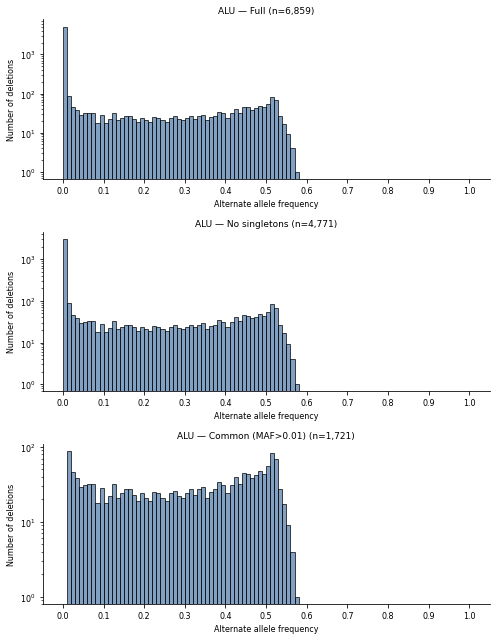

ALU plot saved.
  LINE1 — Full: reading AF...
  LINE1 — No singletons: reading AF...
  LINE1 — Common (MAF>0.01): reading AF...


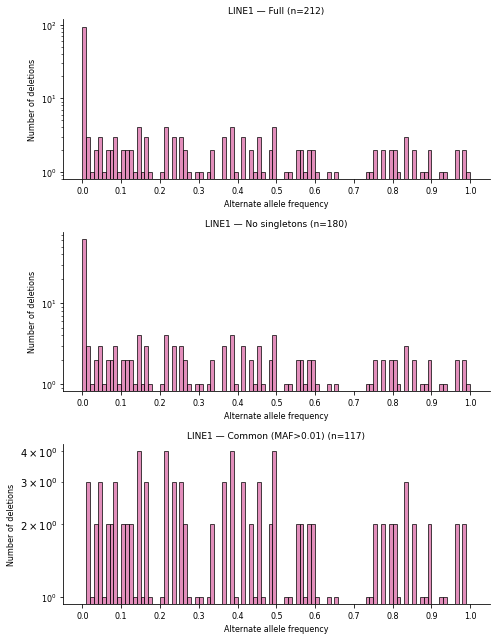

LINE1 plot saved.


In [8]:
vcfs_to_plot = {
    "ALU": {
        "Full":              "/gpfs/data/user/shreyags/TE_work/filtered_vcfs/with_af/ALU_deletions.filtered.final.tagged.vcf.gz",
        "No singletons":     "/gpfs/data/user/shreyags/TE_work/filtered_vcfs/common_nosingletons/ALU_deletions.filtered.final.no_singletons.vcf.gz",
        "Common (MAF>0.01)": "/gpfs/data/user/shreyags/TE_work/filtered_vcfs/common_nosingletons/ALU_deletions.filtered.final.common_maf0.01.vcf.gz",
    },
    "LINE1": {
        "Full":              "/gpfs/data/user/shreyags/TE_work/filtered_vcfs/with_af/LINE1_deletions.filtered.final.tagged.vcf.gz",
        "No singletons":     "/gpfs/data/user/shreyags/TE_work/filtered_vcfs/common_nosingletons/LINE1_deletions.filtered.final.no_singletons.vcf.gz",
        "Common (MAF>0.01)": "/gpfs/data/user/shreyags/TE_work/filtered_vcfs/common_nosingletons/LINE1_deletions.filtered.final.common_maf0.01.vcf.gz",
    },
}

te_colors = {
    "ALU":   "#4C78A8",
    "LINE1": "#D65F9E",
}

def get_af_from_tagged(vcf_path):
    vcf = pysam.VariantFile(vcf_path)
    afs = []
    for rec in vcf.fetch():
        af_val = rec.info.get("AF", None)
        if af_val is not None:
            afs.append(af_val[0] if isinstance(af_val, tuple) else af_val)
    vcf.close()
    return afs

for te_type in ["ALU", "LINE1"]:

    fig, axes = plt.subplots(3, 1, figsize=(7, 9), facecolor="white")

    for ax, (label, path) in zip(axes, vcfs_to_plot[te_type].items()):
        print(f"  {te_type} — {label}: reading AF...")
        afs = get_af_from_tagged(path)

        ax.hist(
            afs,
            bins=np.arange(0, 1.01, 0.01),
            color=te_colors[te_type],
            ec="black",
            alpha=0.7
        )

        ax.set_yscale("log")
        ax.set_xticks(np.arange(0, 1.05, 0.1))
        ax.tick_params(axis="x", labelsize=8)
        ax.tick_params(axis="y", labelsize=8)
        ax.set_ylabel("Number of deletions", fontsize=8)
        ax.set_xlabel("Alternate allele frequency", fontsize=8)
        ax.set_title(f"{te_type} — {label} (n={len(afs):,})", fontsize=9)
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig(
        f"{OUTDIR_PLOTS}/{te_type}_deletion_AF_distributions.png",
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )
    plt.show()
    print(f"{te_type} plot saved.")

  ALU — Full: counting per-sample variants...
  ALU — No singletons: counting per-sample variants...
  ALU — Common (MAF>0.01): counting per-sample variants...


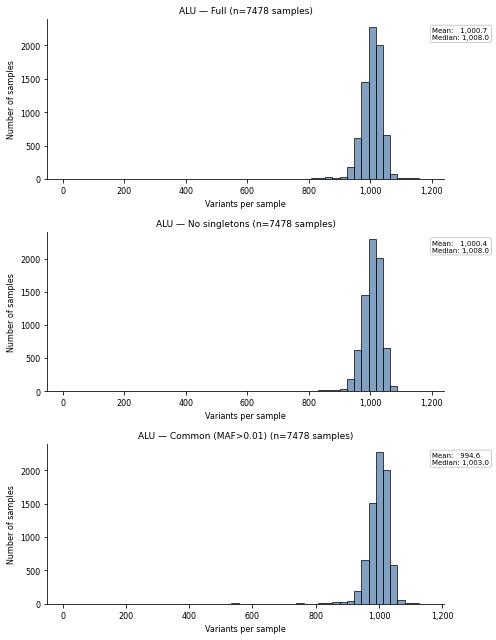

ALU per-sample plot saved.
  LINE1 — Full: counting per-sample variants...
  LINE1 — No singletons: counting per-sample variants...
  LINE1 — Common (MAF>0.01): counting per-sample variants...


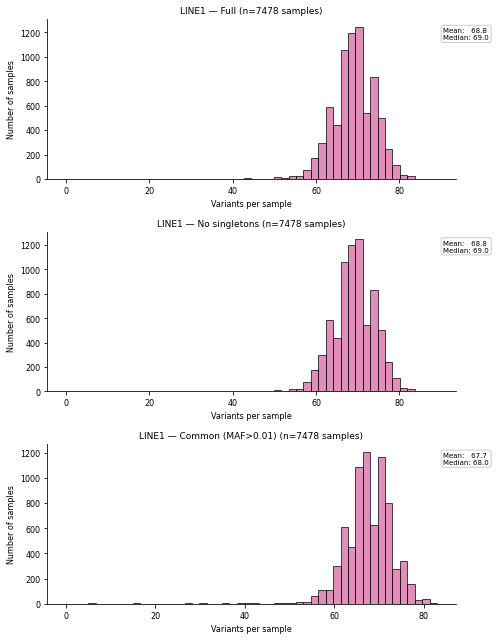

LINE1 per-sample plot saved.


In [12]:
def get_per_sample_counts_from_vcf(vcf_path):
    vcf     = pysam.VariantFile(vcf_path)
    samples = list(vcf.header.samples)
    counts  = {s: 0 for s in samples}
    for rec in vcf.fetch():
        for s in samples:
            gt = rec.samples[s]["GT"]
            if gt is not None and any(a is not None and a > 0 for a in gt):
                counts[s] += 1
    vcf.close()
    return counts

for te_type in ["ALU", "LINE1"]:

    fig, axes = plt.subplots(3, 1, figsize=(7, 9), facecolor="white")

    for ax, (label, path) in zip(axes, vcfs_to_plot[te_type].items()):
        print(f"  {te_type} — {label}: counting per-sample variants...")
        counts = pd.Series(list(get_per_sample_counts_from_vcf(path).values()))

        ax.hist(
            counts,
            bins=50,
            color=te_colors[te_type],
            ec="black",
            alpha=0.7
        )

        ax.tick_params(axis="x", labelsize=8)
        ax.tick_params(axis="y", labelsize=8)
        ax.set_ylabel("Number of samples", fontsize=8)
        ax.set_xlabel("Variants per sample", fontsize=8)
        ax.set_title(f"{te_type} — {label} (n={len(counts)} samples)", fontsize=9)
        ax.spines[["top", "right"]].set_visible(False)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

        # mean and median as text in the plot
        mean   = counts.mean()
        median = counts.median()
        ax.text(
            0.97, 0.95,
            f"Mean:   {mean:,.1f}\nMedian: {median:,.1f}",
            transform=ax.transAxes,
            fontsize=7,
            verticalalignment="top",
            horizontalalignment="left",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#cccccc")
        )

    plt.tight_layout()
    plt.savefig(
        f"{OUTDIR_PLOTS}/{te_type}_deletion_per_sample_distributions.png",
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )
    plt.show()
    print(f"{te_type} per-sample plot saved.")